<a href="https://colab.research.google.com/github/R3beAM/Proyecto-Final-Integracion/blob/main/Parte_2_Proyecto_Final_Integracion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Parte 2 — Exploratory Data Analysis (EDA)**



##1. Carga y revisión inicial

In [1]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string

In [2]:
# Ruta al archivo (ajusta el nombre del archivo)
file_path = "/content/Amazon_Consumer_Review.csv"

# Cargar el dataset en Pandas
df = pd.read_csv(file_path)

# Ver las primeras filas
df.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28332 entries, 0 to 28331
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   28332 non-null  object 
 1   dateAdded            28332 non-null  object 
 2   dateUpdated          28332 non-null  object 
 3   name                 28332 non-null  object 
 4   asins                28332 non-null  object 
 5   brand                28332 non-null  object 
 6   categories           28332 non-null  object 
 7   primaryCategories    28332 non-null  object 
 8   imageURLs            28332 non-null  object 
 9   keys                 28332 non-null  object 
 10  manufacturer         28332 non-null  object 
 11  manufacturerNumber   28332 non-null  object 
 12  reviews.date         28332 non-null  object 
 13  reviews.dateSeen     28332 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doRecommend  16086 non-null 

In [4]:
df.describe()

,reviews.id,reviews.numHelpful,reviews.rating
count,4.100000e+01,16115.000000,28332.000000
mean,1.840066e+08,0.529321,4.514048
std,2.337036e+07,9.345017,0.934957
min,1.116244e+08,0.000000,1.000000
25%,1.843344e+08,0.000000,4.000000
50%,1.885078e+08,0.000000,5.000000
75%,1.988160e+08,0.000000,5.000000
max,2.085304e+08,621.000000,5.000000


In [5]:
df.dtypes

,0
id,object
dateAdded,object
dateUpdated,object
name,object
asins,object
brand,object
categories,object
primaryCategories,object
imageURLs,object
keys,object


##Información general del dataset

El dataset anexado corresponde a una base de datos de reseñas de consumidores sobre productos Amazon. Cada fila representa una opinión escrita por un cliente sobre un producto específico, junto con información asociada como calificación, fecha, producto, categoría, marca, recomendación y votos de utilidad.

Este dataset es adecuado para el proyecto porque contiene texto de reseñas, calificaciones numéricas y variables complementarias que permiten desarrollar un modelo de análisis de sentimiento con Machine Learning y NLP.

| Elemento                                   | Descripción                                                            |
| ------------------------------------------ | ---------------------------------------------------------------------- |
| **Nombre del archivo**                     | `Amazon_Consumer_Review.csv`                                           |
| **Formato**                                | CSV                                                                    |
| **Cantidad de filas**                      | 28,332 registros                                                       |
| **Cantidad de columnas**                   | 24 columnas                                                            |
| **Unidad de análisis**                     | Cada fila representa una reseña de un cliente sobre un producto Amazon |
| **Periodo de reseñas**                     | Aproximadamente de 2009 a 2019                                         |
| **Tipo de problema compatible**            | NLP y clasificación multiclase                                         |
| **Variable principal de texto**            | `reviews.text`                                                         |
| **Variable base para construir el target** | `reviews.rating`                                                       |



###¿Qué contiene el dataset?

El dataset contiene información relacionada con:

* Datos del producto
* Nombre del producto.
* Marca.
* Categoría.
* ASIN o identificador del producto.
Fabricante.
* URLs de imágenes y páginas fuente.
* Datos de la reseña
* Texto completo de la reseña.
* Título de la reseña.
* Calificación dada por el cliente.
* Fecha de la reseña.
* Nombre de usuario.
* Cantidad de votos de utilidad.
* Datos de recomendación
* Si el cliente recomienda o no el producto.
* Si el cliente compró el producto, aunque esta variable tiene muchos datos faltantes.

###**Variables mas importantes para el proyecto**

| Variable              | Descripción                                         | Uso en el proyecto                                                 |
| --------------------- | --------------------------------------------------- | ------------------------------------------------------------------ |
| `reviews.text`        | Texto completo de la reseña escrita por el cliente. | Variable principal para aplicar NLP.                               |
| `reviews.title`       | Título de la reseña.                                | Puede complementar el texto principal.                             |
| `reviews.rating`      | Calificación del producto de 1 a 5 estrellas.       | Se usará para construir el target de sentimiento.                  |
| `reviews.doRecommend` | Indica si el cliente recomienda el producto.        | Variable de apoyo para validar sentimiento.                        |
| `reviews.numHelpful`  | Número de votos de utilidad de la reseña.           | Puede analizarse para ver si las reseñas negativas son más útiles. |
| `reviews.date`        | Fecha de la reseña.                                 | Permite analizar cambios de sentimiento en el tiempo.              |
| `name`                | Nombre del producto reseñado.                       | Permite analizar sentimiento por producto.                         |
| `primaryCategories`   | Categoría principal del producto.                   | Permite analizar sentimiento por categoría.                        |

##Observaciones iniciales sobre los datos

1. El dataset tiene buen tamaño para un proyecto de Machine Learning

Con 28,332 reseñas, el dataset es suficientemente grande para entrenar modelos clásicos de clasificación de texto, como:

Regresión Logística,
Naive Bayes,
Random Forest,
XGBoost, si se desea probar una opción más avanzada.

Al mismo tiempo, no es tan grande como para requerir infraestructura compleja. Puede trabajarse adecuadamente en Google Colab usando CPU.

2. La mayoría de las reseñas son positivas

La distribución de calificaciones muestra un fuerte predominio de reseñas positivas.

|      Rating | Cantidad aproximada | Porcentaje |
| ----------: | ------------------: | ---------: |
|  1 estrella |                 965 |      3.41% |
| 2 estrellas |                 616 |      2.17% |
| 3 estrellas |               1,206 |      4.26% |
| 4 estrellas |               5,648 |     19.94% |
| 5 estrellas |              19,897 |     70.23% |

Esto indica que aproximadamente el 90% de las reseñas tienen calificaciones de 4 o 5 estrellas.

*Observación importante*

Esto representa un posible desbalance de clases. Si el target se construye como:

| Rating | Sentimiento |
| -----: | ----------- |
|  1 o 2 | Negativo    |
|      3 | Neutral     |
|  4 o 5 | Positivo    |

3. El texto de las reseñas está completo

Una observación positiva es que la variable principal del proyecto, reviews.text, no presenta valores nulos. Esto es importante porque el modelo dependerá principalmente del texto para aprender patrones de sentimiento.

También la variable reviews.title está completa, por lo que puede utilizarse como complemento del texto principal.

Una estrategia posible sería crear una variable combinada:

`texto_final = reviews.title + " " + reviews.text`

Esto podría enriquecer el contenido usado por el modelo.

4. Algunas variables tienen muchos valores faltantes

Aunque las variables principales están completas, algunas columnas tienen una alta cantidad de valores nulos.

| Variable              | Observación                                                                                     |
| --------------------- | ----------------------------------------------------------------------------------------------- |
| `reviews.didPurchase` | Tiene casi todos los valores faltantes. No se recomienda usarla.                                |
| `reviews.id`          | Tiene muchos valores faltantes. No aporta valor directo al modelo.                              |
| `reviews.doRecommend` | Tiene una cantidad importante de valores faltantes, pero puede usarse en análisis exploratorio. |
| `reviews.numHelpful`  | Tiene valores faltantes, pero puede ser útil para análisis complementario.                      |

No todas las variables del dataset deben usarse en el modelo. Para evitar ruido, conviene seleccionar solo las variables realmente útiles:

* reviews.text
* reviews.title
* reviews.rating
* reviews.date
* reviews.numHelpful
* reviews.doRecommend
* name
* primaryCategories

5. Hay concentración en pocas categorías y productos

El dataset contiene 65 productos únicos, pero algunas reseñas se concentran en productos específicos, especialmente baterías AmazonBasics y tablets Fire.

Las categorías principales más frecuentes son:

| Categoría                    | Cantidad aproximada de registros |
| ---------------------------- | -------------------------------: |
| Electronics                  |                           13,995 |
| Health & Beauty              |                           12,071 |
| Toys & Games, Electronics    |                            1,676 |
| Office Supplies, Electronics |                              386 |
| Electronics, Media           |                              185 |


6. Hay reseñas repetidas o textos duplicados

Aunque no se identificaron filas completamente duplicadas, sí se observan textos de reseñas repetidos. Esto puede ocurrir porque algunos comentarios se repiten para productos similares, variaciones del mismo producto o registros asociados a distintas fuentes.

Implicación

Antes de entrenar el modelo, conviene revisar los duplicados en reviews.text. Si hay demasiados textos repetidos, podrían afectar el aprendizaje del modelo, especialmente si aparecen tanto en entrenamiento como en prueba.

Una posible acción sería eliminar duplicados basados en:

`reviews.text`

o en una combinación de:

`name + reviews.text + reviews.rating`

La longitud de las reseñas es variada

Las reseñas tienen diferentes extensiones. Algunas son muy cortas, de una sola palabra, mientras que otras son bastante largas.

En promedio, las reseñas tienen aproximadamente 26 palabras, aunque hay casos mucho más extensos.

Implicación

Las reseñas muy cortas pueden ser difíciles de clasificar porque tienen poca información contextual. Por ejemplo:

`"Good"`

o

`"Ok"`

Estas reseñas pueden ser positivas o neutrales dependiendo del contexto. Esto puede generar cierta dificultad para el modelo.


##2. Dimensiones y estructura

In [7]:
df_info = pd.DataFrame({
    'Métrica': ['Cantidad de Filas', 'Cantidad de Columnas'],
    'Valor': [df.shape[0], df.shape[1]]
})
display(df_info)

print("Tamaño del dataset:", df.shape)

,Métrica,Valor
0,Cantidad de Filas,28332
1,Cantidad de Columnas,24


Tamaño del dataset: (28332, 24)


Resumen de valores nulos:


,Valores nulos,Porcentaje de nulos
reviews.didPurchase,28323,99.97
reviews.id,28291,99.86
reviews.doRecommend,12246,43.22
reviews.numHelpful,12217,43.12
reviews.username,5,0.02
id,0,0.00
dateUpdated,0,0.00
dateAdded,0,0.00
primaryCategories,0,0.00
categories,0,0.00


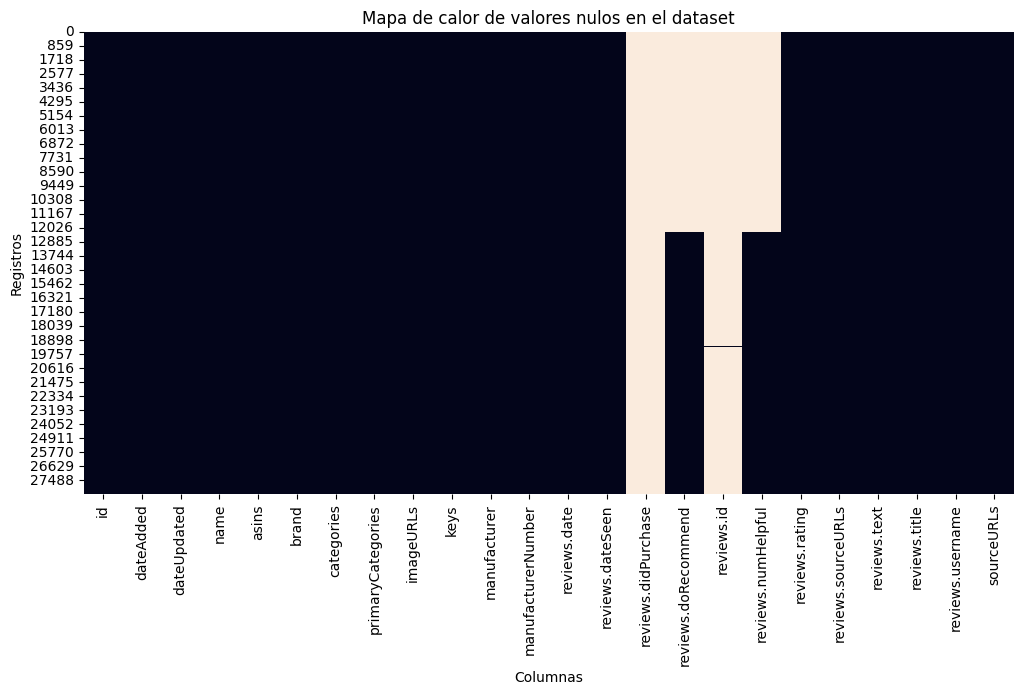

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Amazon_Consumer_Review.csv")

nulos_conteo = df.isnull().sum()
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100

resumen_nulos = pd.DataFrame({
    "Valores nulos": nulos_conteo,
    "Porcentaje de nulos": nulos_porcentaje.round(2)
}).sort_values(by="Porcentaje de nulos", ascending=False)

print("Resumen de valores nulos:")
display(resumen_nulos)

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de calor de valores nulos en el dataset")
plt.xlabel("Columnas")
plt.ylabel("Registros")
plt.show()

***Análisis***

Los resultados muestran que el dataset tiene 24 columnas y que la mayoría de las variables principales para el proyecto están completas. Sin embargo, algunas columnas presentan un porcentaje muy alto de valores nulos y deben tratarse con cuidado.

Las variables de `reviews.didPurchase` y `reviews.id` no se pueden incorporar en el modelo, porque generarían un vicio

| Variable              | Valores nulos | Porcentaje de nulos | Análisis                                                                                                                         |
| --------------------- | ------------: | ------------------: | -------------------------------------------------------------------------------------------------------------------------------- |
| `reviews.didPurchase` |        28,323 |              99.97% | Prácticamente toda la columna está vacía. No es recomendable utilizarla en el análisis ni en el modelo.                          |
| `reviews.id`          |        28,291 |              99.86% | Tiene casi todos los valores faltantes. No aporta valor para el modelo y puede eliminarse.                                       |
| `reviews.doRecommend` |        12,246 |              43.22% | Tiene una cantidad importante de valores nulos. Puede usarse solo como variable complementaria, pero no como variable principal. |
| `reviews.numHelpful`  |        12,217 |              43.12% | Tiene muchos valores faltantes. Puede utilizarse en análisis exploratorio, pero requiere tratamiento de nulos.                   |
| `reviews.username`    |             5 |               0.02% | Tiene muy pocos valores nulos. No representa un problema importante, aunque no es una variable relevante para el modelo.         |


**Variables que pueden conservarse con tratamiento**

Las siguientes variables tienen valores nulos importantes, pero podrían aportar valor en análisis complementarios:

| Variable              | Decisión sugerida                             | Justificación                                                                                                                                                     |
| --------------------- | --------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `reviews.doRecommend` | Conservar solo para análisis exploratorio.    | Puede ayudar a comparar sentimiento con intención de recomendación, pero no debe ser variable principal por tener 43.22% de nulos.                                |
| `reviews.numHelpful`  | Conservar con imputación o análisis separado. | Puede servir para analizar si las reseñas negativas reciben más votos de utilidad. Los nulos podrían reemplazarse por 0 si se interpreta que no recibieron votos. |

**Variables principales completas**

Una observación muy positiva es que las variables más importantes para el proyecto no tienen valores nulos:

| Variable            | Porcentaje de nulos | Importancia                                            |
| ------------------- | ------------------: | ------------------------------------------------------ |
| `reviews.text`      |               0.00% | Variable principal para NLP y análisis de sentimiento. |
| `reviews.title`     |               0.00% | Puede complementar el texto de la reseña.              |
| `reviews.rating`    |               0.00% | Variable clave para construir el target `sentiment`.   |
| `reviews.date`      |               0.00% | Permite análisis temporal.                             |
| `name`              |               0.00% | Permite análisis por producto.                         |
| `primaryCategories` |               0.00% | Permite análisis por categoría.                        |
| `brand`             |               0.00% | Permite análisis por marca.                            |

**Plan potencial de limpieza**

| Acción                   | Variable              | Justificación                                                |
| ------------------------ | --------------------- | ------------------------------------------------------------ |
| Eliminar                 | `reviews.didPurchase` | 99.97% de nulos.                                             |
| Eliminar                 | `reviews.id`          | 99.86% de nulos.                                             |
| Conservar                | `reviews.text`        | Variable principal del modelo.                               |
| Conservar                | `reviews.title`       | Puede mejorar el contexto textual.                           |
| Conservar                | `reviews.rating`      | Necesaria para construir el target.                          |
| Conservar con cuidado    | `reviews.doRecommend` | Útil para análisis complementario, pero con 43.22% de nulos. |
| Conservar con imputación | `reviews.numHelpful`  | Puede reemplazarse nulos por 0 para análisis exploratorio.   |
| Opcional eliminar        | `reviews.username`    | No aporta al modelo y puede excluirse por privacidad.        |


##**Datos duplicados**

In [11]:
# Conteo de filas completamente duplicadas
duplicados_completos = df.duplicated().sum()

print("Cantidad de registros completamente duplicados:", duplicados_completos)
print("Porcentaje de registros duplicados:", round((duplicados_completos / len(df)) * 100, 2), "%")

Cantidad de registros completamente duplicados: 0
Porcentaje de registros duplicados: 0.0 %


In [14]:
#Datos duplicados en la columna de review.text

# Conteo de textos duplicados en reviews.text
duplicados_texto = df["reviews.text"].duplicated().sum()

print("Cantidad de reseñas duplicadas en reviews.text:", duplicados_texto)
print("Porcentaje de reseñas duplicadas:", round((duplicados_texto / len(df)) * 100, 2), "%")

#Ver cuales textos estan duplicados

# Mostrar todas las filas donde reviews.text está duplicado
df_textos_duplicados = df[df["reviews.text"].duplicated(keep=False)]

# Ordenar para ver juntos los textos repetidos
df_textos_duplicados = df_textos_duplicados.sort_values(by="reviews.text")

df_textos_duplicados[["name", "reviews.rating", "reviews.title", "reviews.text"]].head(20)

#Ver un texto duplicado específico con sus filas completas

# Contar la frecuencia de cada texto para encontrar los repetidos
textos_repetidos = df["reviews.text"].value_counts()
textos_repetidos = textos_repetidos[textos_repetidos > 1]

# Seleccionar el texto duplicado más frecuente
texto_mas_repetido = textos_repetidos.index[0]

# Mostrar las filas donde aparece ese texto
df[df["reviews.text"] == texto_mas_repetido][
    ["name", "reviews.rating", "reviews.title", "reviews.text", "reviews.date"]
]


Cantidad de reseñas duplicadas en reviews.text: 10164
Porcentaje de reseñas duplicadas: 35.87 %


,name,reviews.rating,reviews.title,reviews.text,reviews.date
1708,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2015-10-01T00:00:00.000Z
1709,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2016-02-17T00:00:00.000Z
1710,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2015-03-24T00:00:00.000Z
1712,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2016-09-11T00:00:00.000Z
1713,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2016-10-10T00:00:00.000Z
1715,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2016-02-01T00:00:00.000Z
1716,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2017-05-02T00:00:00.000Z
1719,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2016-05-21T00:00:00.000Z
1721,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2016-07-24T00:00:00.000Z
1722,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2017-06-12T00:00:00.000Z


Aunque podría eliminar las entradas duplicadas basados en reviews.text, creo que hay que dejarlos, porque son entradas diferentes, simplemente `good` parece ser un comentario generico muy utilizado

In [ ]:
##Analisis univariado

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

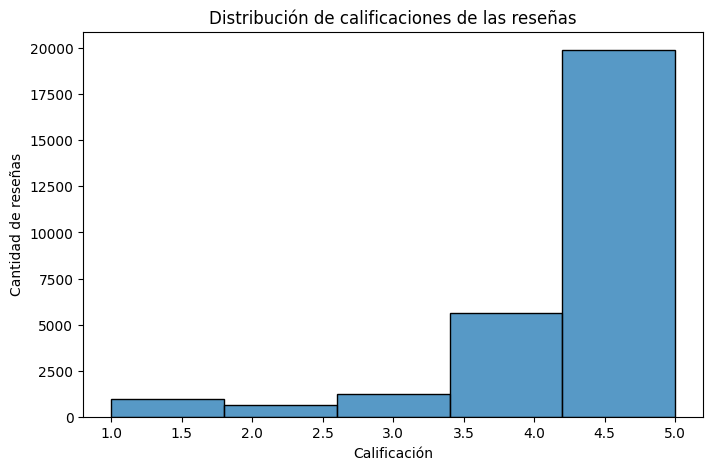

In [16]:
#Histograma de calificaciones reviews.rating

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="reviews.rating",
    bins=5
)

plt.title("Distribución de calificaciones de las reseñas")
plt.xlabel("Calificación")
plt.ylabel("Cantidad de reseñas")
plt.show()

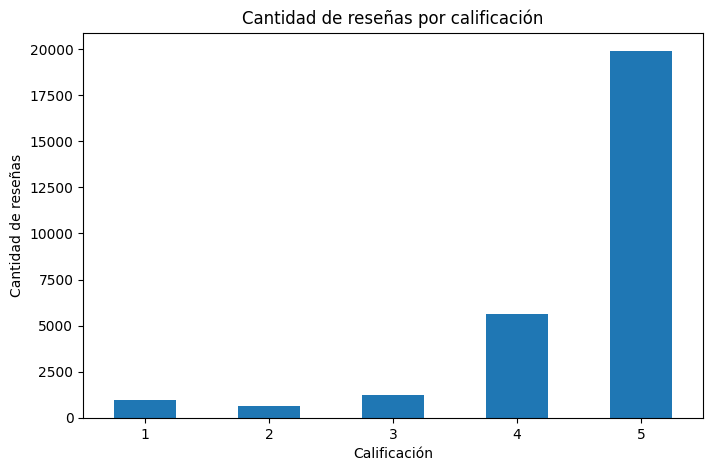

In [17]:
#Grafico de barras de calificaciones

plt.figure(figsize=(8, 5))

df["reviews.rating"].value_counts().sort_index().plot(kind="bar")
3559
plt.title("Cantidad de reseñas por calificación")
plt.xlabel("Calificación")
plt.ylabel("Cantidad de reseñas")
plt.xticks(rotation=0)
plt.show()

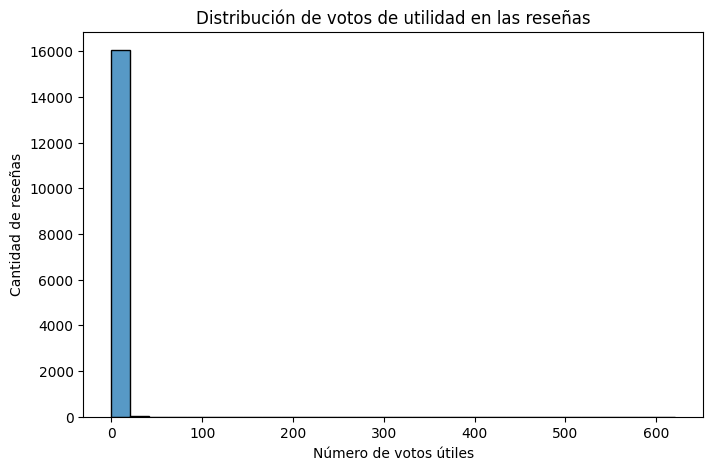

In [18]:
#Histograma de votos útiles reviews.numHelpful

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="reviews.numHelpful",
    bins=30
)

plt.title("Distribución de votos de utilidad en las reseñas")
plt.xlabel("Número de votos útiles")
plt.ylabel("Cantidad de reseñas")
plt.show()

**Analisis**

La mayoria de las reseñas son positivas, y los votos de utilidad parecen ser inexistentes. Contrario a la hipotesis inicial, la mayoría de las reseñas son positivas, y eso puede generar un sesgo en el modelo. Sin embargo, tenerlo claro puede ayudar a gestionarlo

In [19]:
#Creando variable de sentimiento

def clasificar_sentimiento(rating):
    if rating in [1, 2]:
        return "Negativo"
    elif rating == 3:
        return "Neutral"
    elif rating in [4, 5]:
        return "Positivo"
    else:
        return "Sin clasificar"

df["sentiment"] = df["reviews.rating"].apply(clasificar_sentimiento)

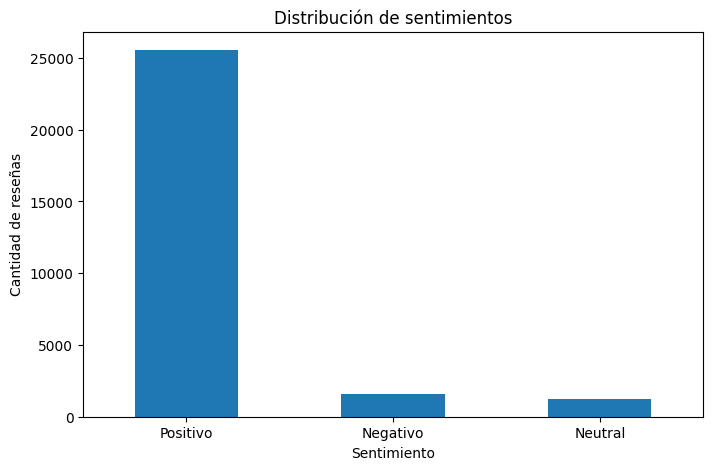

In [20]:
#Distribucion de sentimiento

plt.figure(figsize=(8, 5))

df["sentiment"].value_counts().plot(kind="bar")

plt.title("Distribución de sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de reseñas")
plt.xticks(rotation=0)
plt.show()

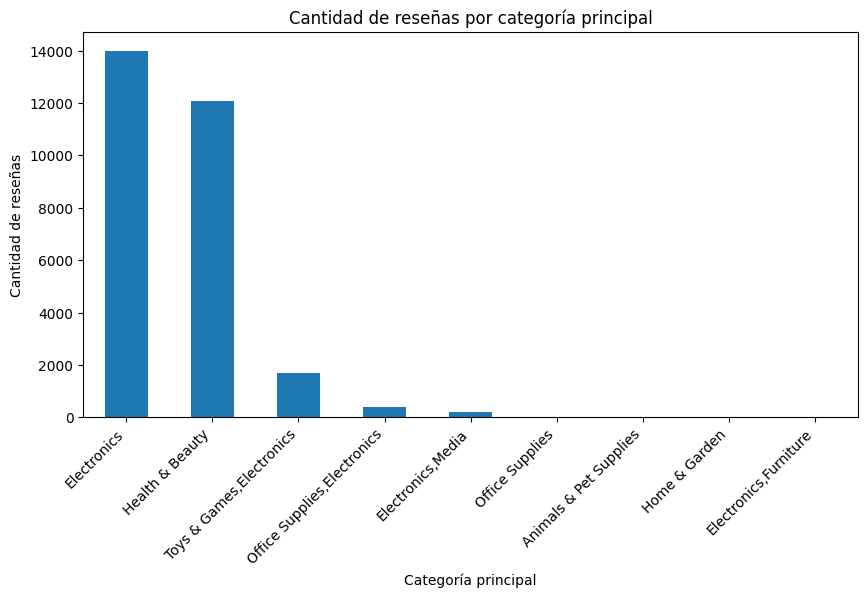

In [21]:
#Histograma por categoría principal

plt.figure(figsize=(10, 5))

df["primaryCategories"].value_counts().plot(kind="bar")

plt.title("Cantidad de reseñas por categoría principal")
plt.xlabel("Categoría principal")
plt.ylabel("Cantidad de reseñas")
plt.xticks(rotation=45, ha="right")
plt.show()

La mayoria de las reseñas estan asociadas a Electronics, entonces podriamos decir que Electronics es la categoria principal con mas reseñas. En esta categoria, Amazon es el principal vendedor, siendo así, el resultado del modelo podria quedar como beneficio interno para la compañía

4. Análisis univariado
________________________________________
Variables numéricas


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Mostrar columnas disponibles
print("Columnas del dataset:")
print(df.columns.tolist())

Columnas del dataset:
['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand', 'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer', 'manufacturerNumber', 'reviews.date', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs', 'sentiment']


In [23]:
#Seleccionar variables numéricas relevantes

#Para este dataset, las variables numéricas más importantes son:

#reviews.rating
#reviews.numHelpful

# Crear variables de longitud del texto
df["review_length_chars"] = df["reviews.text"].astype(str).apply(len)
df["review_length_words"] = df["reviews.text"].astype(str).apply(lambda x: len(x.split()))

# Seleccionar variables numéricas para análisis
variables_numericas = [
    "reviews.rating",
    "reviews.numHelpful",
    "review_length_chars",
    "review_length_words"
]

# Validar cuáles existen en el dataframe
variables_numericas = [col for col in variables_numericas if col in df.columns]

print("Variables numéricas seleccionadas:")
print(variables_numericas)

Variables numéricas seleccionadas:
['reviews.rating', 'reviews.numHelpful', 'review_length_chars', 'review_length_words']


In [24]:
#Media, mediana, moda, percentiles, asimetría y curtosis

resumen_estadistico = []

for col in variables_numericas:
    serie = df[col].dropna()

    resumen_estadistico.append({
        "Variable": col,
        "Cantidad de datos": serie.count(),
        "Media": serie.mean(),
        "Mediana": serie.median(),
        "Moda": serie.mode().iloc[0] if not serie.mode().empty else np.nan,
        "Mínimo": serie.min(),
        "Percentil 25": serie.quantile(0.25),
        "Percentil 50": serie.quantile(0.50),
        "Percentil 75": serie.quantile(0.75),
        "Percentil 90": serie.quantile(0.90),
        "Percentil 95": serie.quantile(0.95),
        "Máximo": serie.max(),
        "Desviación estándar": serie.std(),
        "Asimetría": serie.skew(),
        "Curtosis": serie.kurtosis(),
        "Valores únicos": serie.nunique()
    })

resumen_estadistico = pd.DataFrame(resumen_estadistico)

display(resumen_estadistico)

,Variable,Cantidad de datos,Media,Mediana,Moda,Mínimo,Percentil 25,Percentil 50,Percentil 75,Percentil 90,Percentil 95,Máximo,Desviación estándar,Asimetría,Curtosis,Valores únicos
0,reviews.rating,28332,4.514048,5.0,5.0,1.0,4.0,5.0,5.0,5.0,5.0,5.0,0.934957,-2.346666,5.297528,5
1,reviews.numHelpful,16115,0.529321,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,621.0,9.345017,44.914456,2390.668765,61
2,review_length_chars,28332,137.517118,87.0,50.0,1.0,54.0,87.0,162.0,289.0,402.0,8351.0,199.877736,14.749180,472.187856,875
3,review_length_words,28332,25.945009,17.0,2.0,1.0,10.0,17.0,31.0,55.0,75.0,1539.0,37.075899,14.222436,451.448454,261


In [25]:
#Interpretacion automatica

def interpretar_asimetria(valor):
    if valor > 1:
        return "Sesgo positivo fuerte"
    elif valor > 0.5:
        return "Sesgo positivo moderado"
    elif valor < -1:
        return "Sesgo negativo fuerte"
    elif valor < -0.5:
        return "Sesgo negativo moderado"
    else:
        return "Distribución aproximadamente simétrica"

def interpretar_curtosis(valor):
    if valor > 1:
        return "Alta concentración y posibles colas pesadas"
    elif valor < -1:
        return "Distribución más plana que una normal"
    else:
        return "Curtosis cercana a una distribución normal"

resumen_estadistico["Interpretación asimetría"] = resumen_estadistico["Asimetría"].apply(interpretar_asimetria)
resumen_estadistico["Interpretación curtosis"] = resumen_estadistico["Curtosis"].apply(interpretar_curtosis)

display(resumen_estadistico)

,Variable,Cantidad de datos,Media,Mediana,Moda,Mínimo,Percentil 25,Percentil 50,Percentil 75,Percentil 90,Percentil 95,Máximo,Desviación estándar,Asimetría,Curtosis,Valores únicos,Interpretación asimetría,Interpretación curtosis
0,reviews.rating,28332,4.514048,5.0,5.0,1.0,4.0,5.0,5.0,5.0,5.0,5.0,0.934957,-2.346666,5.297528,5,Sesgo negativo fuerte,Alta concentración y posibles colas pesadas
1,reviews.numHelpful,16115,0.529321,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,621.0,9.345017,44.914456,2390.668765,61,Sesgo positivo fuerte,Alta concentración y posibles colas pesadas
2,review_length_chars,28332,137.517118,87.0,50.0,1.0,54.0,87.0,162.0,289.0,402.0,8351.0,199.877736,14.749180,472.187856,875,Sesgo positivo fuerte,Alta concentración y posibles colas pesadas
3,review_length_words,28332,25.945009,17.0,2.0,1.0,10.0,17.0,31.0,55.0,75.0,1539.0,37.075899,14.222436,451.448454,261,Sesgo positivo fuerte,Alta concentración y posibles colas pesadas


##Análisis estadístico descriptivo de las variables

Los resultados muestran que el dataset tiene variables con distribuciones no normales, alta concentración en ciertos valores y presencia de outliers, especialmente en las variables relacionadas con votos útiles y longitud de las reseñas.

- Variable reviews.rating

| Indicador | Resultado |
| --------- | --------: |
| Media     |      4.51 |
| Mediana   |      5.00 |
| Moda      |      5.00 |
| Mínimo    |      1.00 |
| Máximo    |      5.00 |
| Asimetría |     -2.35 |
| Curtosis  |      5.30 |

La variable reviews.rating presenta una fuerte concentración en calificaciones altas. La media es 4.51, mientras que la mediana y la moda son 5, lo cual indica que la mayoría de los clientes calificaron los productos con la puntuación máxima.

El sesgo negativo fuerte confirma que la distribución está concentrada hacia valores altos, especialmente 5 estrellas, con una cola hacia los valores bajos, como 1 o 2 estrellas.

La curtosis alta indica que los datos están muy concentrados alrededor de ciertos valores, principalmente la calificación 5, y que existen diferencias marcadas con las calificaciones bajas.

**Interpretación para el proyecto**

Esta variable es clave porque se usará para construir el target de sentimiento:

| Rating | Sentimiento |
| -----: | ----------- |
|    1-2 | Negativo    |
|      3 | Neutral     |
|    4-5 | Positivo    |


Sin embargo, los resultados anticipan un posible desbalance de clases, ya que probablemente habrá muchas más reseñas positivas que negativas o neutrales.

*Implicación*

El modelo podría aprender a clasificar demasiadas reseñas como positivas. Por eso, no se debe evaluar únicamente con accuracy. Será necesario usar:

* F1-score macro,
* precision por clase,
* recall por clase,
* matriz de confusión.

**Variable reviews.numHelpful**

| Indicador         | Resultado |
| ----------------- | --------: |
| Cantidad de datos |    16,115 |
| Media             |      0.53 |
| Mediana           |      0.00 |
| Moda              |      0.00 |
| Mínimo            |      0.00 |
| Percentil 95      |      1.00 |
| Máximo            |    621.00 |
| Asimetría         |     44.91 |
| Curtosis          |   2390.67 |

Análisis

La variable reviews.numHelpful presenta una distribución extremadamente sesgada hacia la derecha. La mediana y la moda son 0, lo que significa que la mayoría de las reseñas no recibieron votos de utilidad.

Además, el percentil 95 es 1, lo cual indica que el 95% de las reseñas tiene como máximo 1 voto útil. Sin embargo, el valor máximo es 621, lo que representa un outlier extremo.

La asimetría de 44.91 y la curtosis de 2390.67 confirman una distribución altamente concentrada en 0, con pocos valores extremadamente altos.

Interpretación para el proyecto

Esta variable no debería usarse como predictor principal del modelo, porque tiene muchos valores faltantes y una distribución muy desigual. Sin embargo, puede ser útil para análisis complementarios.

Por ejemplo, puede ayudar a validar la hipótesis:

Las reseñas negativas podrían recibir más votos de utilidad porque los clientes suelen considerar importantes las advertencias antes de comprar.






In [26]:
#**Variables categóricas**

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Si aún no ha cargado el dataset
# df = pd.read_csv("Amazon_Consumer_Review.csv")

# Variables categóricas recomendadas para analizar
variables_categoricas = [
    "brand",
    "manufacturer",
    "primaryCategories",
    "categories",
    "name",
    "asins",
    "reviews.doRecommend",
    "reviews.username"
]

# Validar que existan en el dataset
variables_categoricas = [col for col in variables_categoricas if col in df.columns]

print("Variables categóricas seleccionadas:")
print(variables_categoricas)

Variables categóricas seleccionadas:
['brand', 'manufacturer', 'primaryCategories', 'categories', 'name', 'asins', 'reviews.doRecommend', 'reviews.username']


In [27]:
#Conteos, frecuencias y cardinalidad

resumen_categoricas = []

for col in variables_categoricas:
    total = len(df)
    valores_unicos = df[col].nunique(dropna=False)
    valor_dominante = df[col].value_counts(dropna=False).index[0]
    frecuencia_dominante = df[col].value_counts(dropna=False).iloc[0]
    porcentaje_dominante = (frecuencia_dominante / total) * 100

    categorias_raras = (df[col].value_counts(dropna=False) <= 5).sum()

    resumen_categoricas.append({
        "Variable": col,
        "Cantidad de registros": total,
        "Valores únicos / Cardinalidad": valores_unicos,
        "Categoría dominante": valor_dominante,
        "Frecuencia dominante": frecuencia_dominante,
        "Porcentaje dominante": round(porcentaje_dominante, 2),
        "Categorías raras <= 5 registros": categorias_raras
    })

resumen_categoricas = pd.DataFrame(resumen_categoricas)

display(resumen_categoricas)

,Variable,Cantidad de registros,Valores únicos / Cardinalidad,Categoría dominante,Frecuencia dominante,Porcentaje dominante,Categorías raras <= 5 registros
0,brand,28332,3,Amazon,16153,57.01,0
1,manufacturer,28332,4,Amazon,16130,56.93,1
2,primaryCategories,28332,9,Electronics,13995,49.40,2
3,categories,28332,60,"AA,AAA,Health,Electronics,Health & Household,C...",8343,29.45,19
4,name,28332,65,AmazonBasics AAA Performance Alkaline Batterie...,8343,29.45,20
5,asins,28332,65,"B00QWO9P0O,B00LH3DMUO",8343,29.45,20
6,reviews.doRecommend,28332,3,True,15353,54.19,0
7,reviews.username,28332,16269,ByAmazon Customer,889,3.14,15969


In [28]:
#Conteos y frecuencias por variable

for col in variables_categoricas:
    print(f"\nVariable: {col}")

    conteos = df[col].value_counts(dropna=False)
    frecuencias = df[col].value_counts(normalize=True, dropna=False) * 100

    tabla_frecuencias = pd.DataFrame({
        "Conteo": conteos,
        "Frecuencia (%)": frecuencias.round(2)
    })

    display(tabla_frecuencias.head(15))


Variable: brand


,Conteo,Frecuencia (%)
brand,,
Amazon,16153,57.01
Amazonbasics,12169,42.95
AmazonBasics,10,0.04



Variable: manufacturer


,Conteo,Frecuencia (%)
manufacturer,,
Amazon,16130,56.93
AmazonBasics,12179,42.99
Amazon Digital Services,18,0.06
Amazon.com,5,0.02



Variable: primaryCategories


...

,Conteo,Frecuencia (%)
asins,,
"B00QWO9P0O,B00LH3DMUO",8343,29.45
"B00QWO9P0O,B01IB83NZG,B00MNV8E0C",3728,13.16
B018T075DC,2443,8.62
"B018SZT3BK,B01AHB9CN2",2370,8.37
B018Y226XO,1676,5.92
B018Y22C2Y,1425,5.03
B018Y23MNM,1212,4.28
B018Y22BI4,1024,3.61
B018Y225IA,987,3.48



Variable: reviews.doRecommend


,Conteo,Frecuencia (%)
reviews.doRecommend,,
True,15353,54.19
NaN,12246,43.22
False,733,2.59



Variable: reviews.username


,Conteo,Frecuencia (%)
reviews.username,,
ByAmazon Customer,889,3.14
Mike,63,0.22
ByKindle Customer,45,0.16
Dave,44,0.16
Chris,38,0.13
John,30,0.11
Nana,28,0.10
Anonymous,27,0.10
ByMike,26,0.09


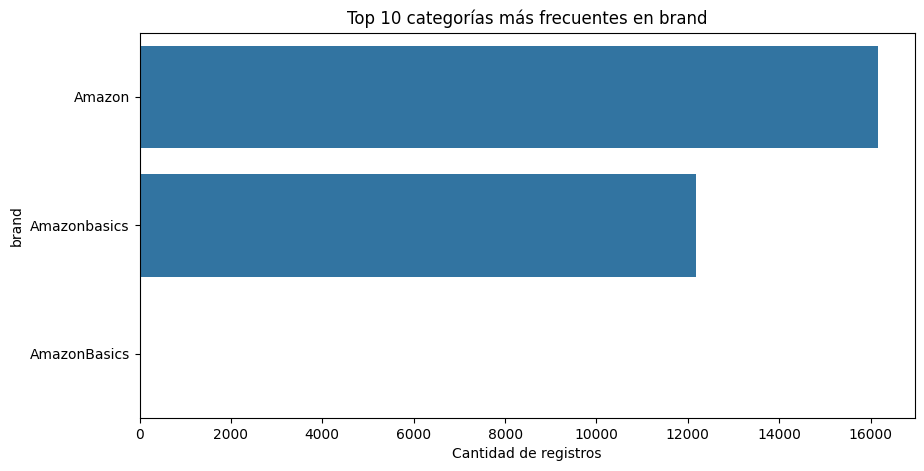

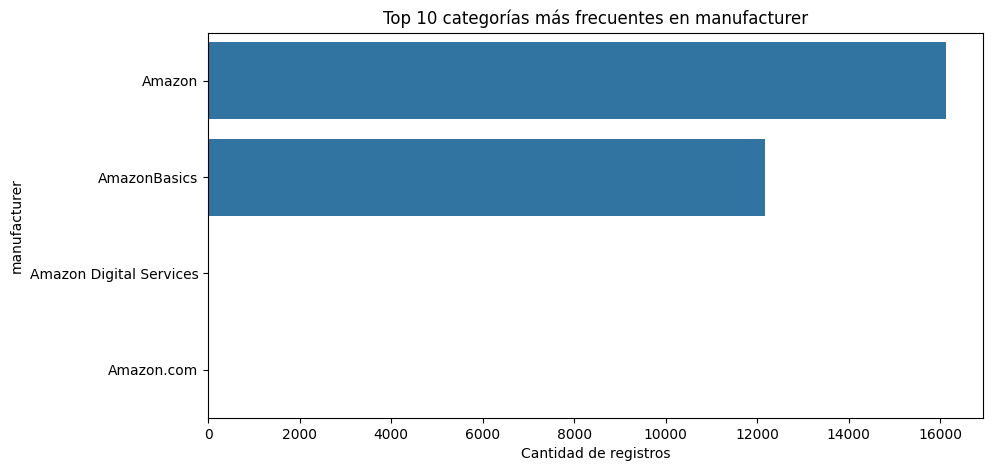

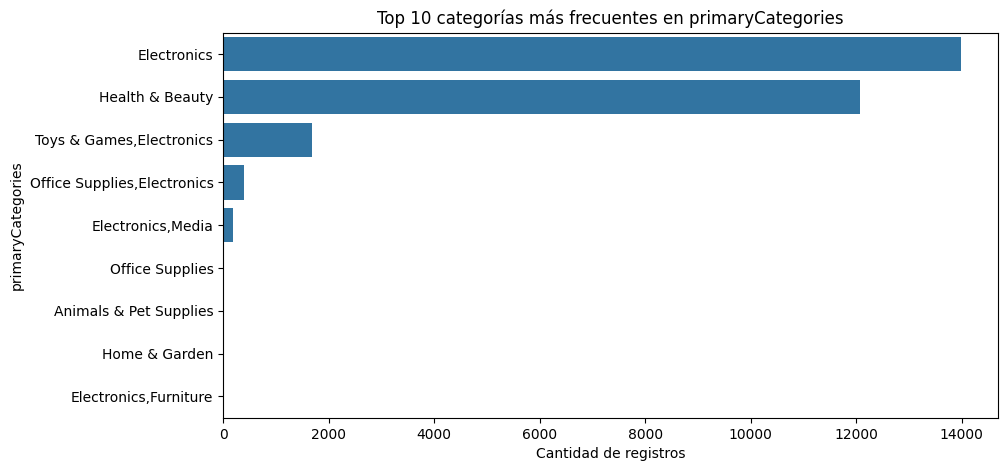

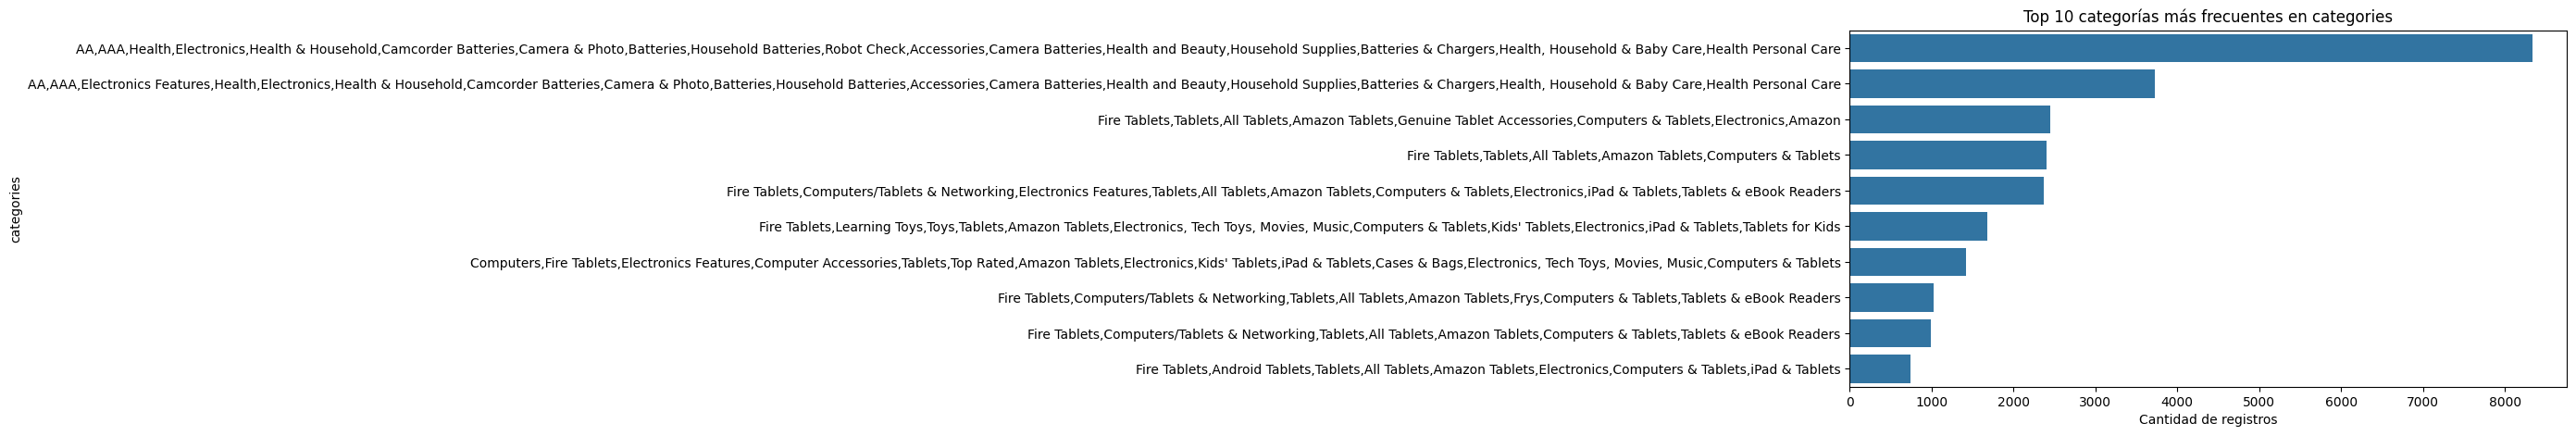

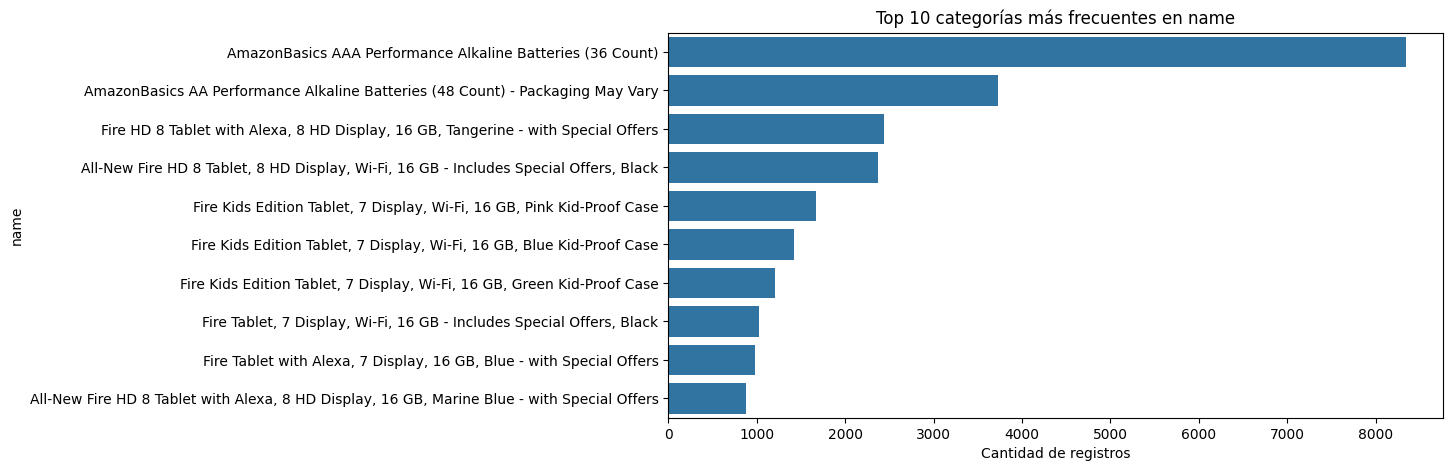

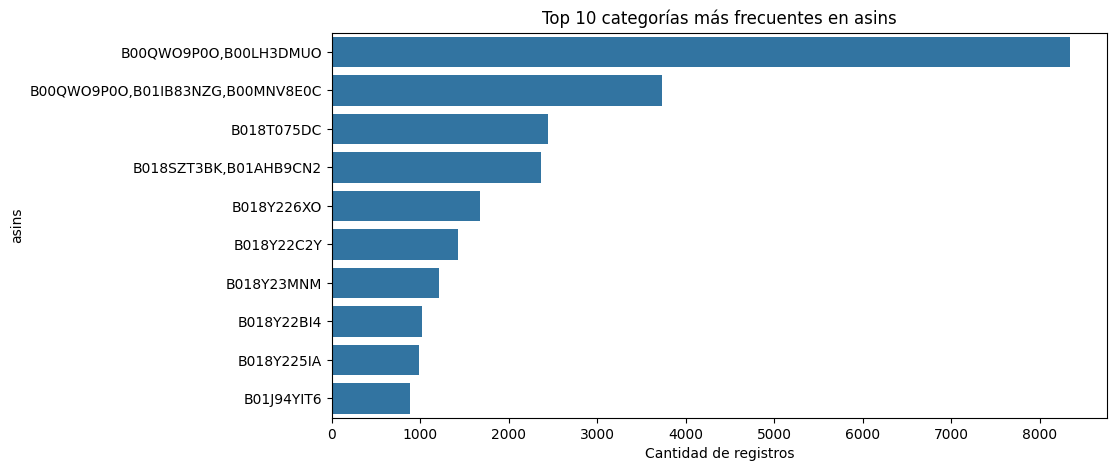

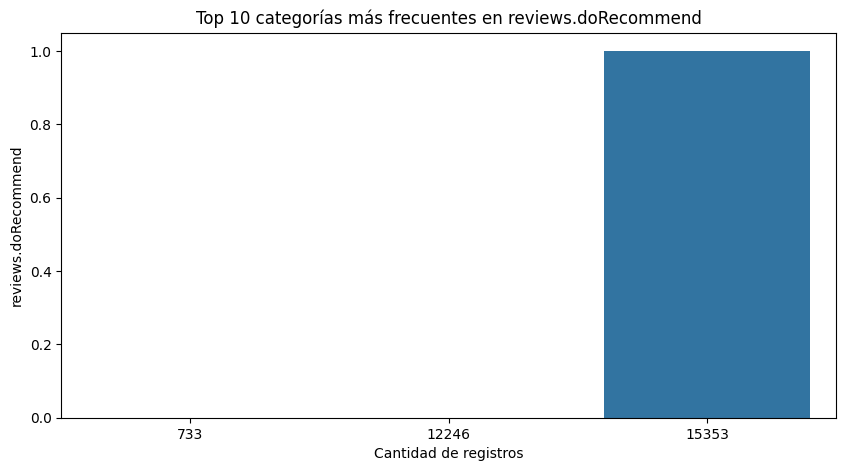

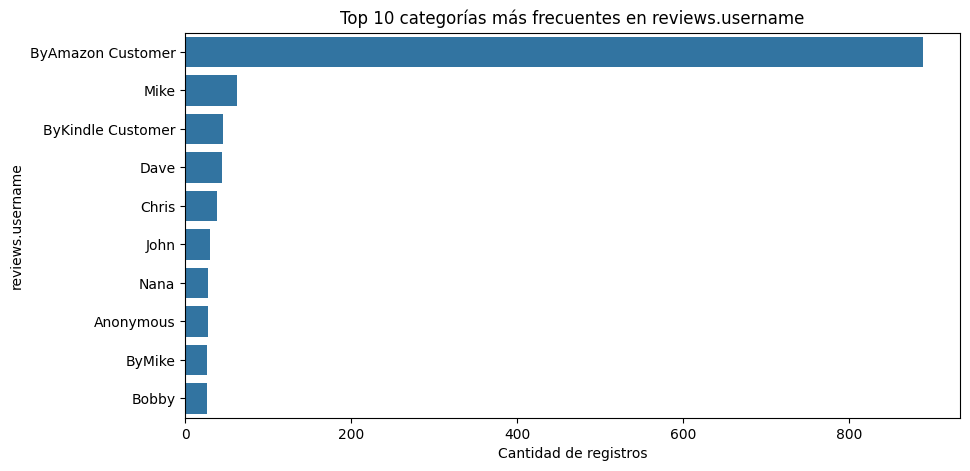

In [29]:
#Gráficos de barras para variables categóricas

for col in variables_categoricas:
    plt.figure(figsize=(10, 5))

    top_categorias = df[col].value_counts(dropna=False).head(10)

    sns.barplot(
        x=top_categorias.values,
        y=top_categorias.index
    )

    plt.title(f"Top 10 categorías más frecuentes en {col}")
    plt.xlabel("Cantidad de registros")
    plt.ylabel(col)
    plt.show()

In [30]:
#Identificar categorías raras

for col in variables_categoricas:
    conteos = df[col].value_counts(dropna=False)
    categorias_raras = conteos[conteos <= 5]

    print(f"\nVariable: {col}")
    print("Cantidad de categorías raras:", len(categorias_raras))

    display(categorias_raras.head(20))


Variable: brand
Cantidad de categorías raras: 0


,count
brand,



Variable: manufacturer
Cantidad de categorías raras: 1


,count
manufacturer,
Amazon.com,5



Variable: primaryCategories
Cantidad de categorías raras: 2


...

,count
asins,
B006LW0W5Y,5
B001NIZB5M,5
B00UH4D8G2,5
B006GWO7UA,5
"B00DIHVMEA,B00EZ1ZTV0",4
B00BGIQS1A,4
B06VTJWRJW,4
B0751RGYJV,3
B00XNQECFM,3



Variable: reviews.doRecommend
Cantidad de categorías raras: 0


,count
reviews.doRecommend,



Variable: reviews.username
Cantidad de categorías raras: 15969


,count
reviews.username,
ByStephanie,5
Mandy,5
Natalie,5
kissesmeow,5
ByGreg,5
Krish,5
FavoriteTT,5
NaN,5
Cruz,5


In [31]:
#Identificar variables con alta cardinalidad

cardinalidad = pd.DataFrame({
    "Variable": variables_categoricas,
    "Cardinalidad": [df[col].nunique(dropna=False) for col in variables_categoricas],
    "Porcentaje de valores únicos": [
        round((df[col].nunique(dropna=False) / len(df)) * 100, 2)
        for col in variables_categoricas
    ]
})

cardinalidad = cardinalidad.sort_values(by="Cardinalidad", ascending=False)

display(cardinalidad)

,Variable,Cardinalidad,Porcentaje de valores únicos
7,reviews.username,16269,57.42
4,name,65,0.23
5,asins,65,0.23
3,categories,60,0.21
2,primaryCategories,9,0.03
1,manufacturer,4,0.01
0,brand,3,0.01
6,reviews.doRecommend,3,0.01


**Análisis**

1. Categorías dominantes

Una categoría dominante ocurre cuando una variable tiene un valor que concentra una gran parte de los registros.

En este dataset, es esperable encontrar categorías dominantes en variables como:

| Variable              | Posible comportamiento esperado                                                 |
| --------------------- | ------------------------------------------------------------------------------- |
| `brand`               | Puede estar altamente concentrada en Amazon o AmazonBasics.                     |
| `manufacturer`        | Puede concentrarse en pocos fabricantes relacionados con Amazon.                |
| `primaryCategories`   | Puede concentrarse en categorías como Electronics o Health & Beauty.            |
| `reviews.doRecommend` | Puede concentrarse en `True`, si la mayoría de clientes recomienda el producto. |


Si una variable tiene una categoría dominante muy fuerte, puede tener poca capacidad explicativa para el modelo, porque no aporta mucha variación. Por ejemplo, si casi todos los productos pertenecen a la misma marca, la variable brand no ayudaría mucho a diferenciar sentimientos.

2. Categorías raras

Las categorías raras son valores que aparecen muy pocas veces en el dataset.

Ejemplos posibles:

productos con 1 o 2 reseñas,
usuarios que solo aparecen una vez,
categorías con muy pocos registros,
códigos ASIN poco frecuentes.
Análisis

Las categorías raras pueden dificultar el análisis porque no hay suficiente información para sacar conclusiones confiables sobre ellas.

Por ejemplo, si un producto tiene solo 2 reseñas negativas, no sería correcto concluir que ese producto tiene mala calidad general. La muestra es demasiado pequeña.

3. Cardinalidad

La cardinalidad indica cuántos valores únicos tiene una variable categórica.

| Variable            | Cardinalidad esperada | Comentario                                                             |
| ------------------- | --------------------- | ---------------------------------------------------------------------- |
| `brand`             | Baja                  | Probablemente pocas marcas.                                            |
| `manufacturer`      | Baja o media          | Puede concentrarse en Amazon.                                          |
| `primaryCategories` | Baja                  | Variable útil para análisis por categoría.                             |
| `name`              | Media                 | Puede haber varios productos únicos.                                   |
| `asins`             | Media o alta          | Identificador de producto. No siempre útil como predictor directo.     |
| `reviews.username`  | Alta                  | No debería usarse como predictor por privacidad y poca generalización. |
| `categories`        | Alta o media          | Puede tener combinaciones largas de categorías.                        |


**Análisis recomendado por variable**

*primaryCategories*

Esta variable es una de las más útiles para el análisis categórico porque permite entender en qué categorías principales se concentran las reseñas.

Se debe analizar:

cantidad de reseñas por categoría,
porcentaje de participación de cada categoría,
categorías con pocas reseñas,
sentimiento por categoría.

Si una o dos categorías concentran la mayoría de registros, el dataset no será completamente representativo de todos los productos Amazon.

*name*

La variable name identifica el producto reseñado.

Se debe analizar:

productos con más reseñas,
productos con menos reseñas,
productos con mayor proporción de comentarios negativos,
concentración de reseñas en pocos productos.

Esta variable puede tener cardinalidad media. Para visualización, se recomienda mostrar únicamente el Top 10 o Top 15 productos más frecuentes.

*brand*

La variable brand permite identificar la marca del producto.

Si la mayoría de registros pertenecen a una sola marca, esta variable tendrá poca variabilidad. En ese caso, será útil para describir el dataset, pero no necesariamente para entrenar el modelo.

*manufacturer*

Esta variable indica el fabricante. Puede comportarse de forma similar a brand.

Si está muy concentrada en pocos fabricantes, puede tener poca utilidad predictiva.

*reviews.doRecommend*

Esta variable indica si el cliente recomienda el producto.

Es categórica/booleana y puede ser muy útil para análisis exploratorio, aunque tiene valores nulos importantes.

Se puede analizar si existe relación entre:

recomendación y rating,
recomendación y sentimiento,
recomendación y longitud de reseña.

*reviews.username*

Esta variable tiene alta cardinalidad porque muchos usuarios aparecen una sola vez.

No se recomienda usarla en el modelo por tres razones:

No aporta valor generalizable.
Puede introducir ruido.
Tiene implicaciones de privacidad.

Puede eliminarse del dataset de modelado.

In [32]:
#Variable objetivo vs variables numéricas

#1. Crear una variable objetivo sentiment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Si aún no ha cargado el dataset:
# df = pd.read_csv("Amazon_Consumer_Review.csv")

# Crear variable objetivo a partir de reviews.rating
def clasificar_sentimiento(rating):
    if rating in [1, 2]:
        return "Negativo"
    elif rating == 3:
        return "Neutral"
    elif rating in [4, 5]:
        return "Positivo"
    else:
        return np.nan

df["sentiment"] = df["reviews.rating"].apply(clasificar_sentimiento)

# Ver distribución del target
df["sentiment"].value_counts()

,count
sentiment,
Positivo,25545
Negativo,1581
Neutral,1206


In [33]:
#Crear variables numéricas derivadas del texto

# Longitud del texto en caracteres
df["review_length_chars"] = df["reviews.text"].astype(str).apply(len)

# Longitud del texto en palabras
df["review_length_words"] = df["reviews.text"].astype(str).apply(lambda x: len(x.split()))

# Asegurar que reviews.numHelpful sea numérica
df["reviews.numHelpful"] = pd.to_numeric(df["reviews.numHelpful"], errors="coerce")

# Variables numéricas para comparar contra el target
variables_numericas = [
    "reviews.rating",
    "reviews.numHelpful",
    "review_length_chars",
    "review_length_words"
]

variables_numericas

['reviews.rating',
 'reviews.numHelpful',
 'review_length_chars',
 'review_length_words']

In [34]:
#Tabla resumen por clase de sentimiento
resumen_por_sentimiento = df.groupby("sentiment")[variables_numericas].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

display(resumen_por_sentimiento)

reviews.rating                                     \
                   count      mean median       std min max   
sentiment                                                     
Negativo            1581  1.389627    1.0  0.487820   1   2   
Neutral             1206  3.000000    3.0  0.000000   3   3   
Positivo           25545  4.778900    5.0  0.414996   4   5   

          reviews.numHelpful                              ...  \
                       count      mean median        std  ...   
sentiment                                                 ...   
Negativo                 428  3.455607    0.0  34.881269  ...   
Neutral                  659  0.279211    0.0   2.367660  ...   
Positivo               15028  0.456947    0.0   7.653485  ...   

          review_length_chars                       review_length_words  \
                       median         std min   max               count   
sentiment                                                                 
Negativo                137.0  223.150685   5  2551                1581   
Neutral                 104.5  202.677019   1  2405                1206   
Positivo                 85.0  197.132943   1  8351               25545   

                                                  
                mean median        std min   max  
sentiment                                         
Negativo   39.674889   26.0  41.300312   1   423  
Neutral    31.436982   20.0  37.439530   1   407  
Positivo   24.835976   16.0  36.587576   1  1539  

[3 rows x 24 columns]

Esta tabla permite comparar la media, mediana, desviación estándar, mínimo y máximo de cada variable numérica según el sentimiento.

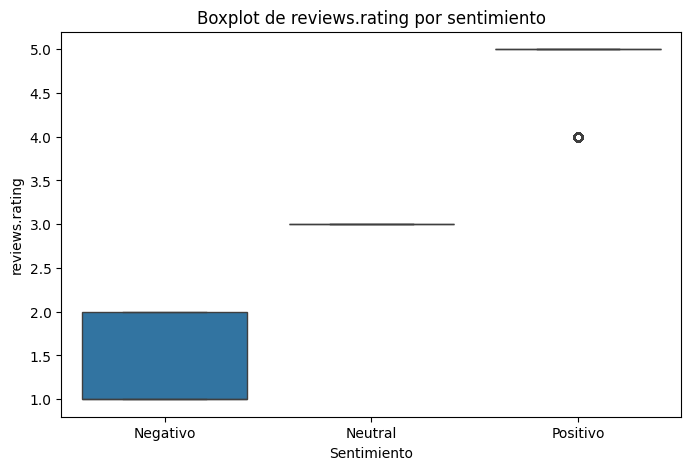

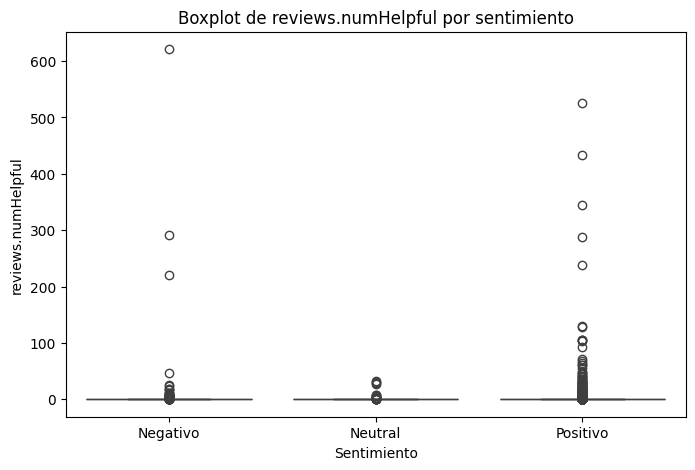

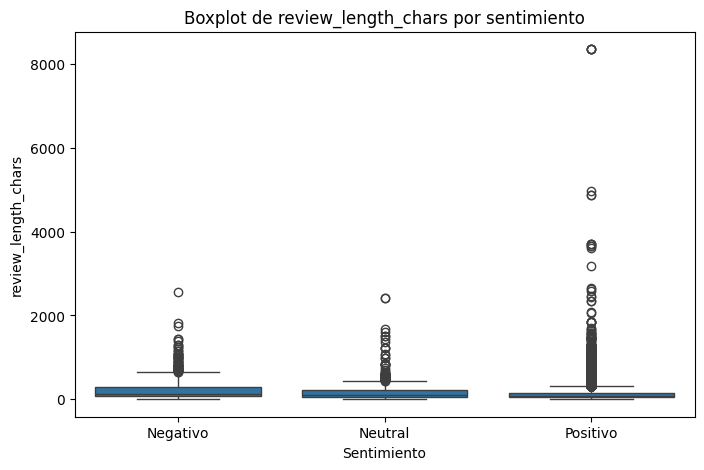

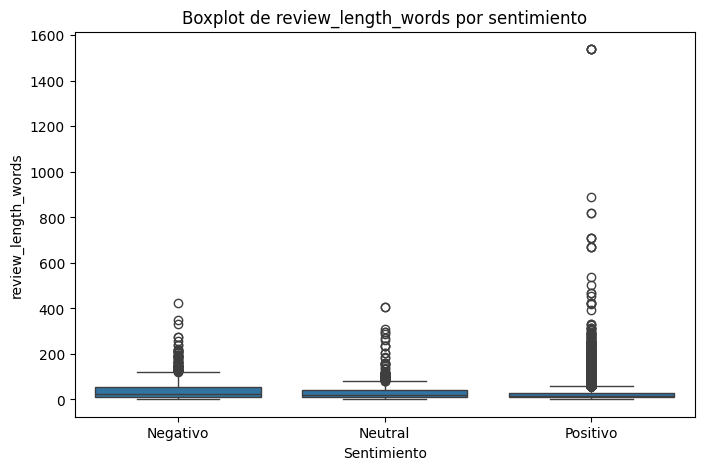

In [35]:
#Boxplots por clase

for col in variables_numericas:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="sentiment",
        y=col,
        order=["Negativo", "Neutral", "Positivo"]
    )

    plt.title(f"Boxplot de {col} por sentimiento")
    plt.xlabel("Sentimiento")
    plt.ylabel(col)
    plt.show()

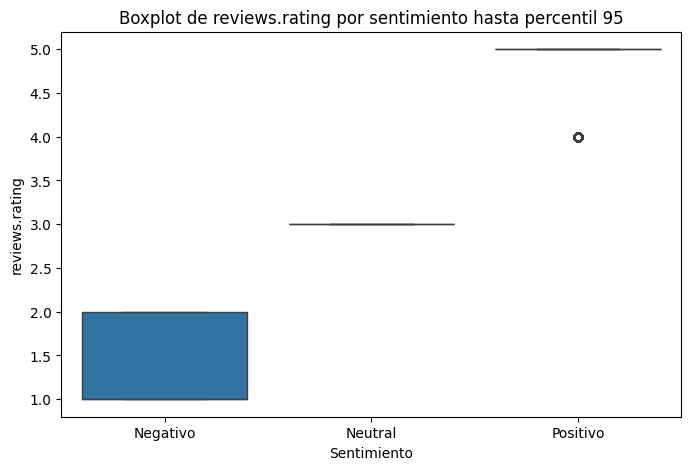

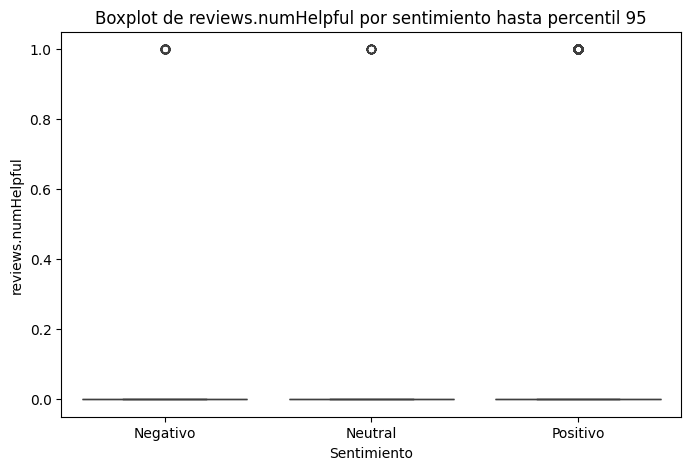

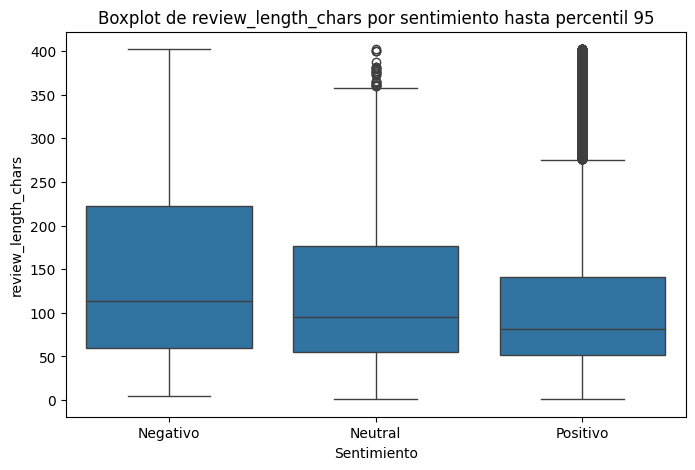

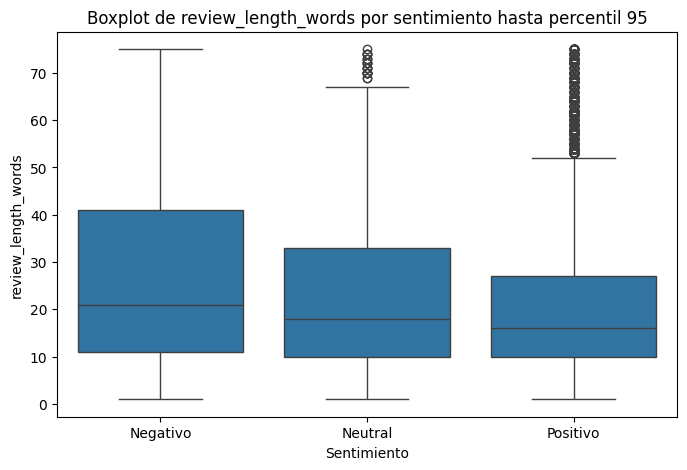

In [36]:
#Boxplots limitando outliers extremos

for col in variables_numericas:
    p95 = df[col].dropna().quantile(0.95)

    df_filtrado = df[df[col] <= p95]

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df_filtrado,
        x="sentiment",
        y=col,
        order=["Negativo", "Neutral", "Positivo"]
    )

    plt.title(f"Boxplot de {col} por sentimiento hasta percentil 95")
    plt.xlabel("Sentimiento")
    plt.ylabel(col)
    plt.show()

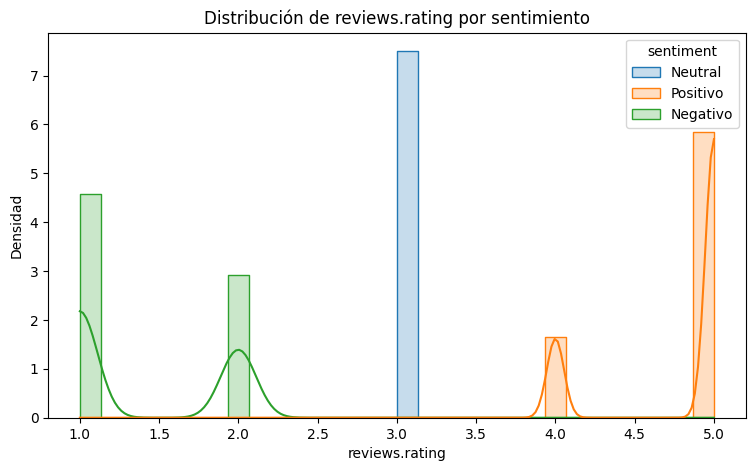

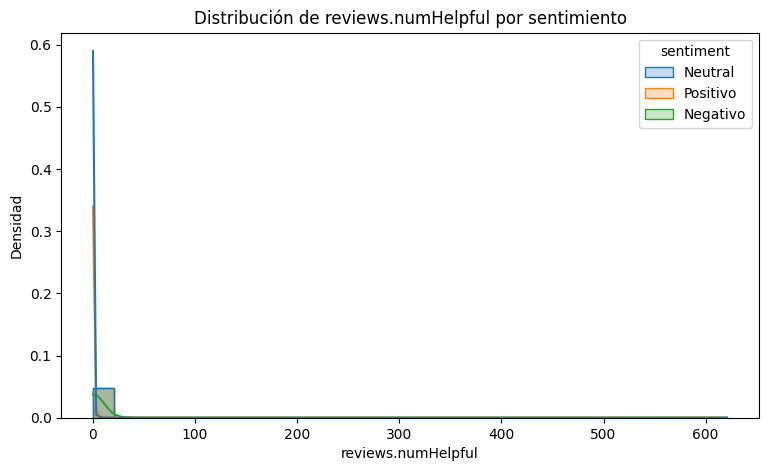

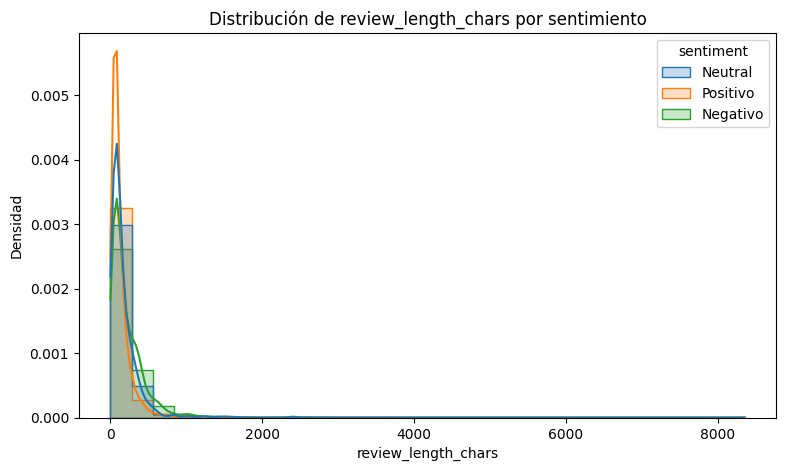

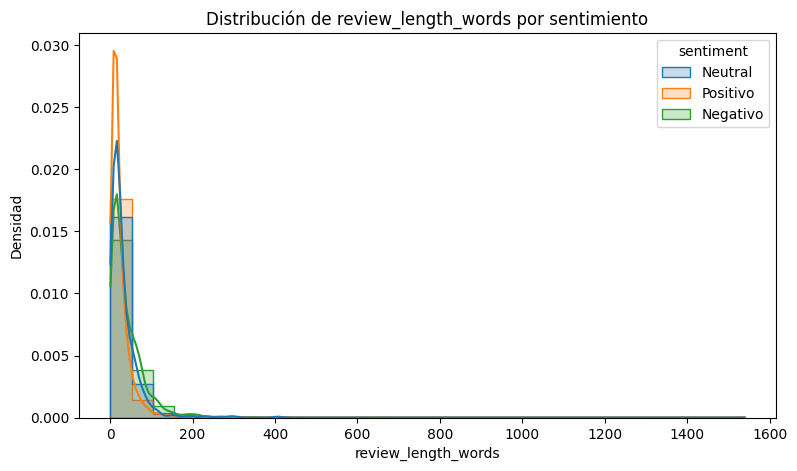

In [37]:
#Distribuciones separadas por sentimiento

for col in variables_numericas:
    plt.figure(figsize=(9, 5))

    sns.histplot(
        data=df,
        x=col,
        hue="sentiment",
        bins=30,
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(f"Distribución de {col} por sentimiento")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.show()

In [38]:
#Tabla de analisis

tabla_analisis = []

for col in variables_numericas:
    for sentimiento in ["Negativo", "Neutral", "Positivo"]:
        serie = df[df["sentiment"] == sentimiento][col].dropna()

        tabla_analisis.append({
            "Variable": col,
            "Sentimiento": sentimiento,
            "Cantidad": serie.count(),
            "Media": round(serie.mean(), 2),
            "Mediana": round(serie.median(), 2),
            "Desviación estándar": round(serie.std(), 2),
            "Mínimo": serie.min(),
            "Máximo": serie.max()
        })

tabla_analisis = pd.DataFrame(tabla_analisis)

display(tabla_analisis)

,Variable,Sentimiento,Cantidad,Media,Mediana,Desviación estándar,Mínimo,Máximo
0,reviews.rating,Negativo,1581,1.39,1.0,0.49,1.0,2.0
1,reviews.rating,Neutral,1206,3.00,3.0,0.00,3.0,3.0
2,reviews.rating,Positivo,25545,4.78,5.0,0.41,4.0,5.0
3,reviews.numHelpful,Negativo,428,3.46,0.0,34.88,0.0,621.0
4,reviews.numHelpful,Neutral,659,0.28,0.0,2.37,0.0,33.0
5,reviews.numHelpful,Positivo,15028,0.46,0.0,7.65,0.0,525.0
6,review_length_chars,Negativo,1581,213.45,137.0,223.15,5.0,2551.0
7,review_length_chars,Neutral,1206,165.71,104.5,202.68,1.0,2405.0
8,review_length_chars,Positivo,25545,131.49,85.0,197.13,1.0,8351.0
9,review_length_words,Negativo,1581,39.67,26.0,41.30,1.0,423.0


**Análisis esperado de los resultados**

1. reviews.rating vs sentiment

Esta comparación debe mostrar una separación perfecta o casi perfecta entre clases, porque la variable sentiment fue construida directamente a partir de reviews.rating.

Por definición:

| Rating | Sentimiento |
| -----: | ----------- |
|  1 o 2 | Negativo    |
|      3 | Neutral     |
|  4 o 5 | Positivo    |


Por esta razón, reviews.rating no debería utilizarse como variable predictora dentro del modelo, porque generaría data leakage.

Interpretación

reviews.rating sirve para construir el target, pero no debe incluirse como entrada del modelo de Machine Learning. El modelo debe aprender principalmente desde el texto de la reseña, no desde la calificación.

2. reviews.numHelpful vs sentiment

Esta variable permite analizar si las reseñas negativas, neutrales o positivas reciben más votos de utilidad.

Un resultado posible es que las reseñas negativas tengan una media más alta de votos útiles. Esto podría indicar que los compradores consideran más útiles las advertencias o experiencias negativas antes de tomar una decisión de compra.

Sin embargo, esta variable tiene muchos valores en 0 y outliers extremos, por lo que se debe interpretar con cuidado. En este caso, la mediana puede ser más representativa que la media.

Interpretación

Si las reseñas negativas tienen mayor media o mediana de votos útiles, se puede apoyar la hipótesis de que los comentarios negativos tienen mayor valor informativo para otros compradores.

3. review_length_chars vs sentiment

Esta variable permite analizar si las reseñas negativas, neutrales o positivas tienden a ser más largas en caracteres.

Es común que las reseñas negativas sean más extensas porque los usuarios suelen explicar con más detalle qué problema tuvieron con el producto. También puede ocurrir que las reseñas positivas sean más cortas y directas.


Si las reseñas negativas tienen mayor longitud promedio, esto puede indicar que los clientes insatisfechos explican más detalles sobre su experiencia. Esto puede ser útil para análisis de oportunidades de mejora.

4. review_length_words vs sentiment

Esta variable mide la longitud de las reseñas en palabras. Su interpretación es similar a la longitud en caracteres, pero puede ser más intuitiva.

Si la mediana de palabras es mayor en la clase negativa, puede sugerir que los clientes escriben reseñas más detalladas cuando tienen una mala experiencia.

**Análisis final**

La longitud del texto puede servir como variable exploratoria, aunque el modelo principal utilizará el contenido textual vectorizado con TF-IDF.


El análisis de la variable objetivo frente a variables numéricas permite identificar diferencias entre las reseñas positivas, negativas y neutrales. La variable reviews.rating muestra una separación directa entre las clases de sentimiento, ya que fue utilizada para construir el target. Por esta razón, no debe usarse como variable predictora dentro del modelo para evitar fuga de información.

La variable reviews.numHelpful permite explorar si algunos sentimientos reciben más votos de utilidad que otros. Debido a que esta variable presenta muchos valores en cero y valores extremos, debe analizarse usando tanto la media como la mediana. Si las reseñas negativas presentan mayor cantidad de votos útiles, esto puede indicar que los consumidores consideran más valiosas las advertencias o malas experiencias antes de comprar un producto.

Las variables review_length_chars y review_length_words permiten analizar la extensión de las reseñas por clase de sentimiento. Si las reseñas negativas tienen mayor longitud promedio, esto podría indicar que los clientes insatisfechos tienden a explicar con mayor detalle los problemas encontrados. En cambio, si las reseñas positivas son más cortas, esto puede reflejar opiniones simples y directas como “great product” o “love it”.

En general, este análisis permite comprender mejor el comportamiento de las clases de sentimiento y detectar patrones que pueden complementar el modelo de Machine Learning. Sin embargo, para el entrenamiento principal, se recomienda utilizar el texto procesado mediante técnicas de NLP como TF-IDF, evitando incluir variables que puedan introducir fuga de información, como reviews.rating

**Variable objetivo vs variables categóricas**

Aquí tiene código para analizar la variable objetivo sentiment vs variables categóricas, incluyendo:

Tablas cruzadas
Proporciones
Distribuciones por clase
Gráficos de barras

In [40]:
#Crear la variable objetivo sentiment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Crear variable objetivo a partir de reviews.rating
def clasificar_sentimiento(rating):
    if rating in [1, 2]:
        return "Negativo"
    elif rating == 3:
        return "Neutral"
    elif rating in [4, 5]:
        return "Positivo"
    else:
        return np.nan

df["sentiment"] = df["reviews.rating"].apply(clasificar_sentimiento)

# Revisar distribución del target
df["sentiment"].value_counts()

,count
sentiment,
Positivo,25545
Negativo,1581
Neutral,1206


In [41]:
#Seleccionar variables categóricas relevantes

variables_categoricas = [
    "primaryCategories",
    "brand",
    "manufacturer",
    "name",
    "reviews.doRecommend"
]

# Validar que existan en el dataframe
variables_categoricas = [col for col in variables_categoricas if col in df.columns]

print("Variables categóricas seleccionadas:")
print(variables_categoricas)

Variables categóricas seleccionadas:
['primaryCategories', 'brand', 'manufacturer', 'name', 'reviews.doRecommend']


In [42]:
#Tablas cruzadas: conteos absolutos

for col in variables_categoricas:
    print(f"\nTabla cruzada de {col} vs sentiment")

    tabla_cruzada = pd.crosstab(
        df[col],
        df["sentiment"]
    )

    display(tabla_cruzada.head(15))


Tabla cruzada de primaryCategories vs sentiment


sentiment,Negativo,Neutral,Positivo
primaryCategories,,,
Animals & Pet Supplies,0,1,5
Electronics,370,551,13074
"Electronics,Furniture",0,0,2
"Electronics,Media",4,3,178
Health & Beauty,1146,534,10391
Home & Garden,0,0,2
Office Supplies,0,0,9
"Office Supplies,Electronics",7,24,355
"Toys & Games,Electronics",54,93,1529



Tabla cruzada de brand vs sentiment


sentiment,Negativo,Neutral,Positivo
brand,,,
Amazon,432,659,15062
AmazonBasics,0,1,9
Amazonbasics,1149,546,10474



Tabla cruzada de manufacturer vs sentiment


sentiment,Negativo,Neutral,Positivo
manufacturer,,,
Amazon,424,659,15047
Amazon Digital Services,5,0,13
Amazon.com,3,0,2
AmazonBasics,1149,547,10483



Tabla cruzada de name vs sentiment


sentiment,Negativo,Neutral,Positivo
name,,,
"All-New Fire 7 Tablet with Alexa, 7"" Display, 8 GB - Marine Blue",2,2,78
"All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Blue Kid-Proof Case",9,10,214
"All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Pink Kid-Proof Case",6,11,276
"All-New Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Marine Blue - with Special Offers",15,45,823
"All-New Fire HD 8 Tablet with Alexa, 8 HD Display, 32 GB, Marine Blue - with Special Offers",5,2,153
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Black",47,80,2243
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Blue",2,0,65
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Black",5,4,131
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Blue",5,3,148



Tabla cruzada de reviews.doRecommend vs sentiment


sentiment,Negativo,Neutral,Positivo
reviews.doRecommend,,,
False,392,254,87
True,26,405,14922


In [43]:
#Tablas cruzadas con proporciones por fila

for col in variables_categoricas:
    print(f"\nProporciones por categoría: {col} vs sentiment")

    proporciones = pd.crosstab(
        df[col],
        df["sentiment"],
        normalize="index"
    ) * 100

    display(proporciones.round(2).head(15))


Proporciones por categoría: primaryCategories vs sentiment


sentiment,Negativo,Neutral,Positivo
primaryCategories,,,
Animals & Pet Supplies,0.00,16.67,83.33
Electronics,2.64,3.94,93.42
"Electronics,Furniture",0.00,0.00,100.00
"Electronics,Media",2.16,1.62,96.22
Health & Beauty,9.49,4.42,86.08
Home & Garden,0.00,0.00,100.00
Office Supplies,0.00,0.00,100.00
"Office Supplies,Electronics",1.81,6.22,91.97
"Toys & Games,Electronics",3.22,5.55,91.23



Proporciones por categoría: brand vs sentiment


sentiment,Negativo,Neutral,Positivo
brand,,,
Amazon,2.67,4.08,93.25
AmazonBasics,0.00,10.00,90.00
Amazonbasics,9.44,4.49,86.07



Proporciones por categoría: manufacturer vs sentiment


sentiment,Negativo,Neutral,Positivo
manufacturer,,,
Amazon,2.63,4.09,93.29
Amazon Digital Services,27.78,0.00,72.22
Amazon.com,60.00,0.00,40.00
AmazonBasics,9.43,4.49,86.07



Proporciones por categoría: name vs sentiment


sentiment,Negativo,Neutral,Positivo
name,,,
"All-New Fire 7 Tablet with Alexa, 7"" Display, 8 GB - Marine Blue",2.44,2.44,95.12
"All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Blue Kid-Proof Case",3.86,4.29,91.85
"All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Pink Kid-Proof Case",2.05,3.75,94.20
"All-New Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Marine Blue - with Special Offers",1.70,5.10,93.20
"All-New Fire HD 8 Tablet with Alexa, 8 HD Display, 32 GB, Marine Blue - with Special Offers",3.12,1.25,95.62
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Black",1.98,3.38,94.64
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Blue",2.99,0.00,97.01
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Black",3.57,2.86,93.57
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Blue",3.21,1.92,94.87



Proporciones por categoría: reviews.doRecommend vs sentiment


sentiment,Negativo,Neutral,Positivo
reviews.doRecommend,,,
False,53.48,34.65,11.87
True,0.17,2.64,97.19


In [44]:
#Tablas cruzadas con conteos y proporciones juntas

for col in variables_categoricas:
    print(f"\nResumen combinado para {col}")

    conteos = pd.crosstab(df[col], df["sentiment"])

    proporciones = pd.crosstab(
        df[col],
        df["sentiment"],
        normalize="index"
    ) * 100

    resumen = conteos.astype(str) + " (" + proporciones.round(1).astype(str) + "%)"

    display(resumen.head(15))


Resumen combinado para primaryCategories


sentiment,Negativo,Neutral,Positivo
primaryCategories,,,
Animals & Pet Supplies,0 (0.0%),1 (16.7%),5 (83.3%)
Electronics,370 (2.6%),551 (3.9%),13074 (93.4%)
"Electronics,Furniture",0 (0.0%),0 (0.0%),2 (100.0%)
"Electronics,Media",4 (2.2%),3 (1.6%),178 (96.2%)
Health & Beauty,1146 (9.5%),534 (4.4%),10391 (86.1%)
Home & Garden,0 (0.0%),0 (0.0%),2 (100.0%)
Office Supplies,0 (0.0%),0 (0.0%),9 (100.0%)
"Office Supplies,Electronics",7 (1.8%),24 (6.2%),355 (92.0%)
"Toys & Games,Electronics",54 (3.2%),93 (5.5%),1529 (91.2%)



Resumen combinado para brand


sentiment,Negativo,Neutral,Positivo
brand,,,
Amazon,432 (2.7%),659 (4.1%),15062 (93.2%)
AmazonBasics,0 (0.0%),1 (10.0%),9 (90.0%)
Amazonbasics,1149 (9.4%),546 (4.5%),10474 (86.1%)



Resumen combinado para manufacturer


sentiment,Negativo,Neutral,Positivo
manufacturer,,,
Amazon,424 (2.6%),659 (4.1%),15047 (93.3%)
Amazon Digital Services,5 (27.8%),0 (0.0%),13 (72.2%)
Amazon.com,3 (60.0%),0 (0.0%),2 (40.0%)
AmazonBasics,1149 (9.4%),547 (4.5%),10483 (86.1%)



Resumen combinado para name


sentiment,Negativo,Neutral,Positivo
name,,,
"All-New Fire 7 Tablet with Alexa, 7"" Display, 8 GB - Marine Blue",2 (2.4%),2 (2.4%),78 (95.1%)
"All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Blue Kid-Proof Case",9 (3.9%),10 (4.3%),214 (91.8%)
"All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Pink Kid-Proof Case",6 (2.0%),11 (3.8%),276 (94.2%)
"All-New Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Marine Blue - with Special Offers",15 (1.7%),45 (5.1%),823 (93.2%)
"All-New Fire HD 8 Tablet with Alexa, 8 HD Display, 32 GB, Marine Blue - with Special Offers",5 (3.1%),2 (1.2%),153 (95.6%)
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Black",47 (2.0%),80 (3.4%),2243 (94.6%)
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Blue",2 (3.0%),0 (0.0%),65 (97.0%)
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Black",5 (3.6%),4 (2.9%),131 (93.6%)
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Blue",5 (3.2%),3 (1.9%),148 (94.9%)



Resumen combinado para reviews.doRecommend


sentiment,Negativo,Neutral,Positivo
reviews.doRecommend,,,
False,392 (53.5%),254 (34.7%),87 (11.9%)
True,26 (0.2%),405 (2.6%),14922 (97.2%)


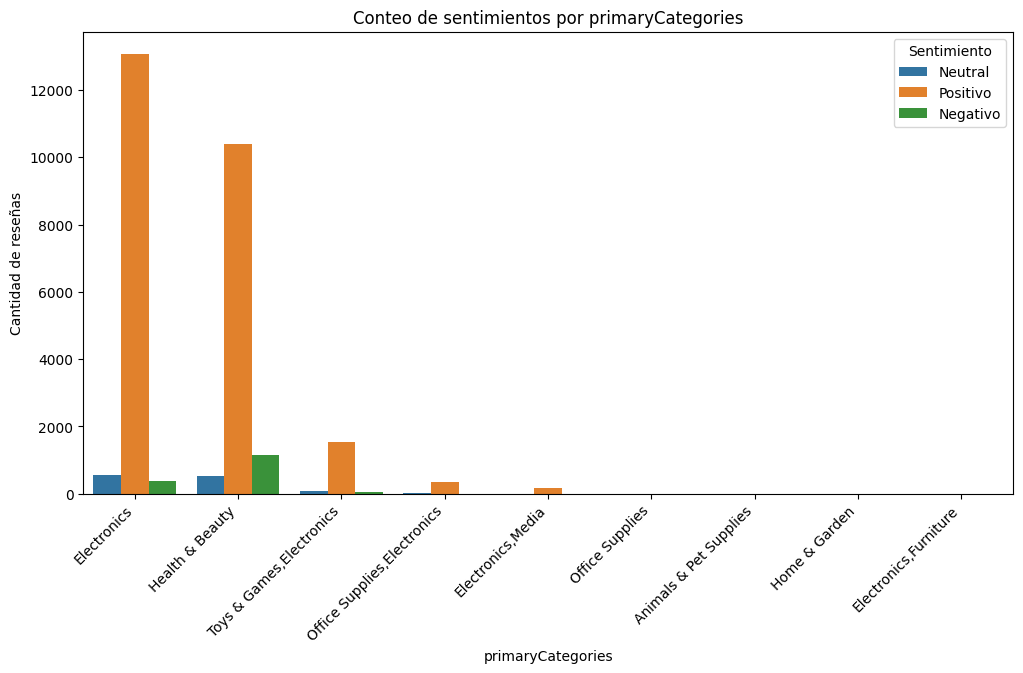

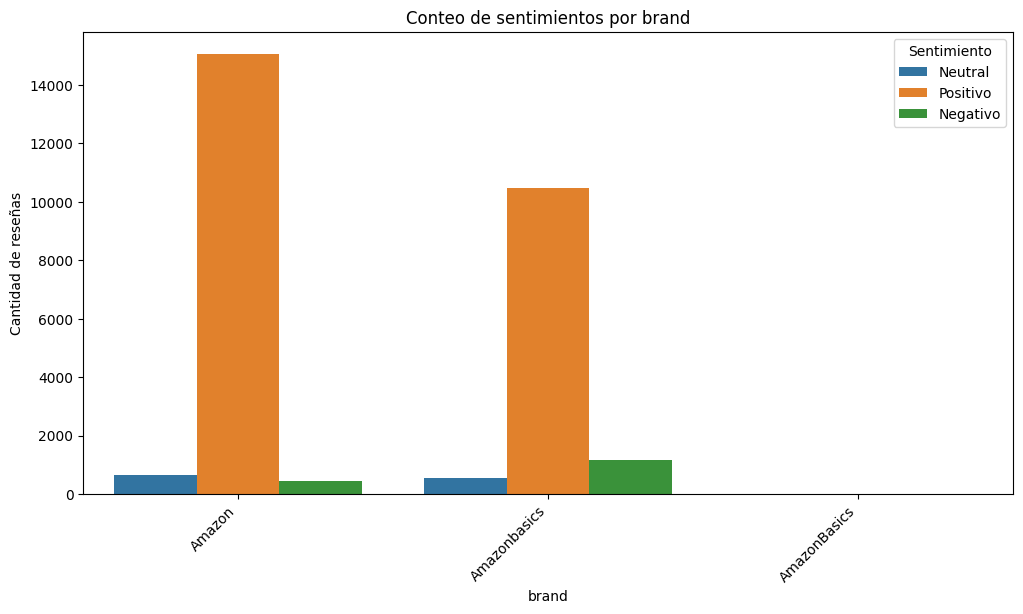

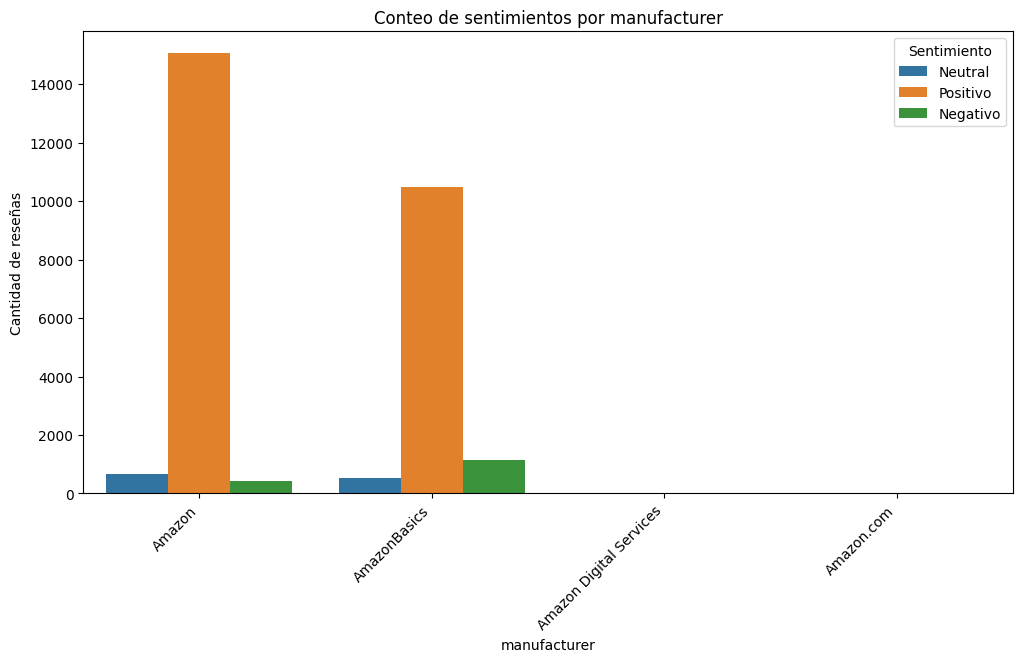

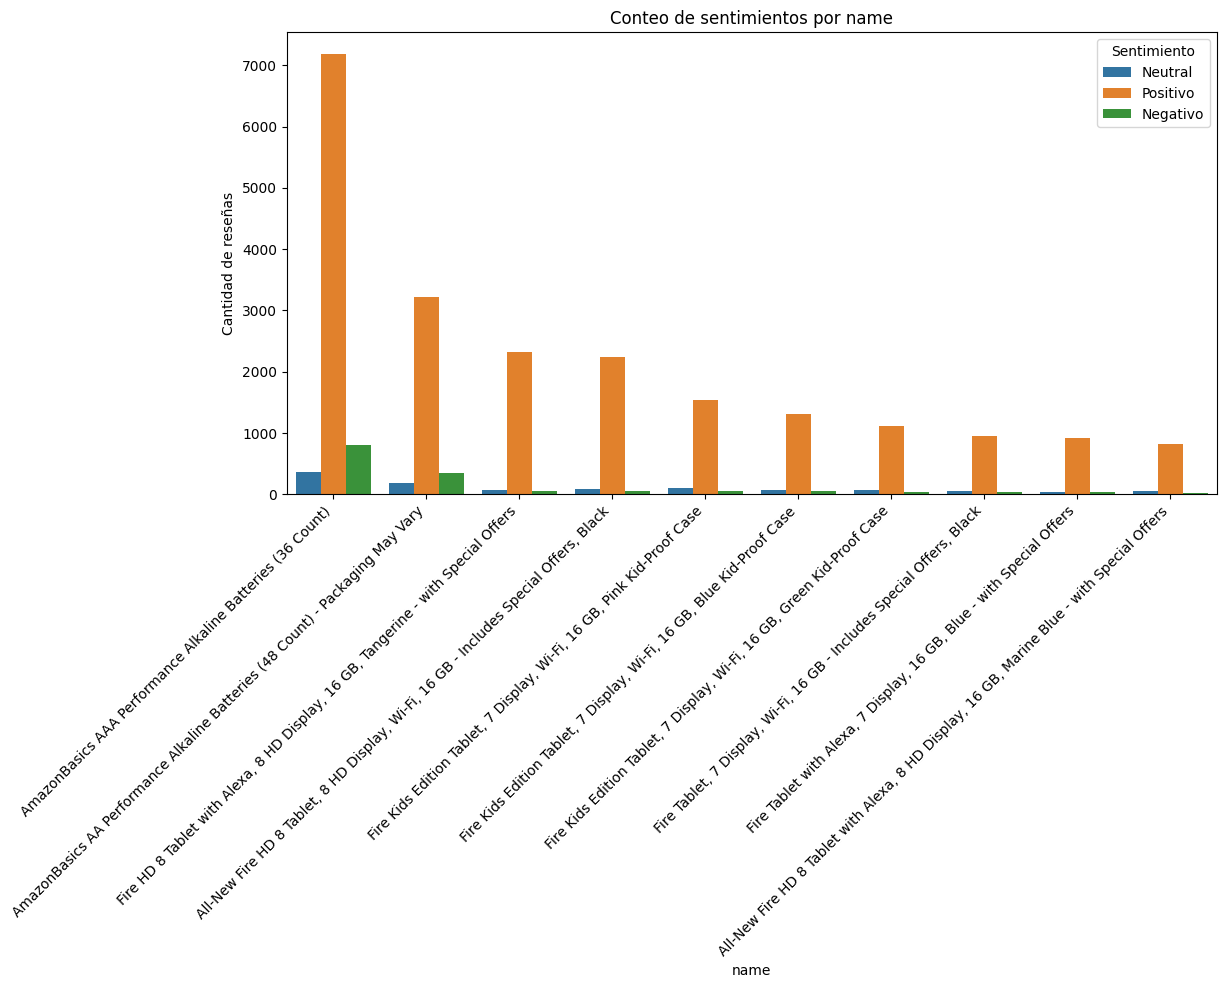

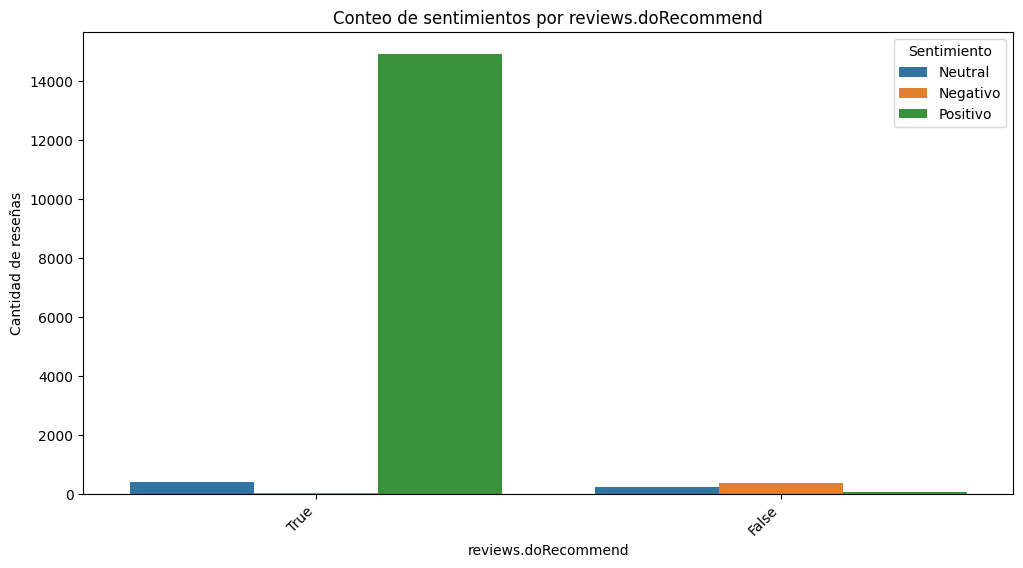

In [45]:
#Conteo de sentimientos por categoría

for col in variables_categoricas:
    top_categorias = df[col].value_counts().head(10).index
    df_top = df[df[col].isin(top_categorias)]

    plt.figure(figsize=(12, 6))

    sns.countplot(
        data=df_top,
        x=col,
        hue="sentiment",
        order=top_categorias
    )

    plt.title(f"Conteo de sentimientos por {col}")
    plt.xlabel(col)
    plt.ylabel("Cantidad de reseñas")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Sentimiento")
    plt.show()

In [46]:
#Identificar categorías con mayor proporción de reseñas negativas

#Este análisis es muy importante para el negocio, porque permite identificar productos o categorías con más insatisfacción.

for col in variables_categoricas:
    print(f"\nCategorías con mayor proporción de sentimiento negativo en {col}")

    conteos = pd.crosstab(df[col], df["sentiment"])

    proporciones = pd.crosstab(
        df[col],
        df["sentiment"],
        normalize="index"
    ) * 100

    # Agregar total de reseñas por categoría
    proporciones["Total reseñas"] = conteos.sum(axis=1)

    # Evitar conclusiones sobre categorías con muy pocos registros
    proporciones_filtradas = proporciones[proporciones["Total reseñas"] >= 20]

    if "Negativo" in proporciones_filtradas.columns:
        resultado = proporciones_filtradas.sort_values(
            by="Negativo",
            ascending=False
        )

        display(resultado.head(10).round(2))
    else:
        print("No existe la clase Negativo en esta variable.")


Categorías con mayor proporción de sentimiento negativo en primaryCategories


sentiment,Negativo,Neutral,Positivo,Total reseñas
primaryCategories,,,,
Health & Beauty,9.49,4.42,86.08,12071
"Toys & Games,Electronics",3.22,5.55,91.23,1676
Electronics,2.64,3.94,93.42,13995
"Electronics,Media",2.16,1.62,96.22,185
"Office Supplies,Electronics",1.81,6.22,91.97,386



Categorías con mayor proporción de sentimiento negativo en brand


sentiment,Negativo,Neutral,Positivo,Total reseñas
brand,,,,
Amazonbasics,9.44,4.49,86.07,12169
Amazon,2.67,4.08,93.25,16153



Categorías con mayor proporción de sentimiento negativo en manufacturer


sentiment,Negativo,Neutral,Positivo,Total reseñas
manufacturer,,,,
AmazonBasics,9.43,4.49,86.07,12179
Amazon,2.63,4.09,93.29,16130



Categorías con mayor proporción de sentimiento negativo en name


sentiment,Negativo,Neutral,Positivo,Total reseñas
name,,,,
AmazonBasics AAA Performance Alkaline Batteries (36 Count),9.62,4.30,86.07,8343
AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary,9.20,4.69,86.11,3728
AmazonBasics 15.6-Inch Laptop and Tablet Bag,4.76,4.76,90.48,21
"All-New Kindle Oasis E-reader - 7 High-Resolution Display (300 ppi), Waterproof, Built-In Audible, 8 GB, Wi-Fi - Includes Special Offers",4.55,0.00,95.45,22
"All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Blue Kid-Proof Case",3.86,4.29,91.85,233
"Kindle Oasis E-reader with Leather Charging Cover - Black, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers",3.64,1.82,94.55,55
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Black",3.57,2.86,93.57,140
Amazon Tap Smart Assistant Alexaenabled (black) Brand New,3.49,4.66,91.85,601
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Blue Kid-Proof Case",3.30,5.19,91.51,1425



Categorías con mayor proporción de sentimiento negativo en reviews.doRecommend


sentiment,Negativo,Neutral,Positivo,Total reseñas
reviews.doRecommend,,,,
False,53.48,34.65,11.87,733
True,0.17,2.64,97.19,15353


In [47]:
#Identificar categorías con mayor proporción de reseñas positivas

for col in variables_categoricas:
    print(f"\nCategorías con mayor proporción de sentimiento positivo en {col}")

    conteos = pd.crosstab(df[col], df["sentiment"])

    proporciones = pd.crosstab(
        df[col],
        df["sentiment"],
        normalize="index"
    ) * 100

    proporciones["Total reseñas"] = conteos.sum(axis=1)

    proporciones_filtradas = proporciones[proporciones["Total reseñas"] >= 20]

    if "Positivo" in proporciones_filtradas.columns:
        resultado = proporciones_filtradas.sort_values(
            by="Positivo",
            ascending=False
        )

        display(resultado.head(10).round(2))
    else:
        print("No existe la clase Positivo en esta variable.")


Categorías con mayor proporción de sentimiento positivo en primaryCategories


sentiment,Negativo,Neutral,Positivo,Total reseñas
primaryCategories,,,,
"Electronics,Media",2.16,1.62,96.22,185
Electronics,2.64,3.94,93.42,13995
"Office Supplies,Electronics",1.81,6.22,91.97,386
"Toys & Games,Electronics",3.22,5.55,91.23,1676
Health & Beauty,9.49,4.42,86.08,12071



Categorías con mayor proporción de sentimiento positivo en brand


sentiment,Negativo,Neutral,Positivo,Total reseñas
brand,,,,
Amazon,2.67,4.08,93.25,16153
Amazonbasics,9.44,4.49,86.07,12169



Categorías con mayor proporción de sentimiento positivo en manufacturer


sentiment,Negativo,Neutral,Positivo,Total reseñas
manufacturer,,,,
Amazon,2.63,4.09,93.29,16130
AmazonBasics,9.43,4.49,86.07,12179



Categorías con mayor proporción de sentimiento positivo en name


sentiment,Negativo,Neutral,Positivo,Total reseñas
name,,,,
"Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Free 3G + Wi-Fi - Includes Special Offers",0.00,0.00,100.00,36
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Blue",2.99,0.00,97.01,67
"Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers",1.19,2.38,96.44,505
"Kindle Oasis E-reader with Leather Charging Cover - Merlot, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers",1.85,1.85,96.30,54
"Amazon Fire HD 8 with Alexa (8"" HD Display Tablet)",3.08,0.77,96.15,130
"All-New Fire HD 8 Tablet with Alexa, 8 HD Display, 32 GB, Marine Blue - with Special Offers",3.12,1.25,95.62,160
"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 GB, Tangerine - with Special Offers",2.56,1.92,95.51,156
"All-New Kindle Oasis E-reader - 7 High-Resolution Display (300 ppi), Waterproof, Built-In Audible, 8 GB, Wi-Fi - Includes Special Offers",4.55,0.00,95.45,22
"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Tangerine - with Special Offers",1.80,3.03,95.17,2443



Categorías con mayor proporción de sentimiento positivo en reviews.doRecommend


sentiment,Negativo,Neutral,Positivo,Total reseñas
reviews.doRecommend,,,,
True,0.17,2.64,97.19,15353
False,53.48,34.65,11.87,733


In [48]:
#Cardinalidad y distribución por clase

#Este bloque permite ver cuántos valores únicos tiene cada variable categórica y cómo se relaciona con el target.

resumen_categoricas_target = []

for col in variables_categoricas:
    valores_unicos = df[col].nunique(dropna=False)
    total_registros = len(df)

    categoria_dominante = df[col].value_counts(dropna=False).index[0]
    frecuencia_dominante = df[col].value_counts(dropna=False).iloc[0]
    porcentaje_dominante = (frecuencia_dominante / total_registros) * 100

    resumen_categoricas_target.append({
        "Variable": col,
        "Cardinalidad": valores_unicos,
        "Categoría dominante": categoria_dominante,
        "Frecuencia dominante": frecuencia_dominante,
        "Porcentaje dominante": round(porcentaje_dominante, 2)
    })

resumen_categoricas_target = pd.DataFrame(resumen_categoricas_target)

display(resumen_categoricas_target)

,Variable,Cardinalidad,Categoría dominante,Frecuencia dominante,Porcentaje dominante
0,primaryCategories,9,Electronics,13995,49.40
1,brand,3,Amazon,16153,57.01
2,manufacturer,4,Amazon,16130,56.93
3,name,65,AmazonBasics AAA Performance Alkaline Batterie...,8343,29.45
4,reviews.doRecommend,3,True,15353,54.19


**Análisis de los resultados**
1. Tablas cruzadas

Las tablas cruzadas permiten observar cuántas reseñas positivas, negativas y neutrales existen dentro de cada variable categórica. Por ejemplo, al cruzar primaryCategories con sentiment, se puede identificar si una categoría de productos concentra más comentarios negativos o positivos.

Este análisis es útil porque no solo muestra el volumen total de reseñas, sino también cómo se distribuye el sentimiento dentro de cada grupo.

2. Proporciones

Las proporciones son más útiles que los conteos absolutos cuando se comparan categorías con tamaños diferentes.

Por ejemplo, si un producto tiene 2,000 reseñas y 100 negativas, puede parecer que tiene muchos comentarios negativos. Pero si otro producto tiene 50 reseñas y 20 negativas, proporcionalmente el segundo producto tiene una situación más crítica.

Por eso, para identificar categorías con mayor insatisfacción, se recomienda analizar el porcentaje de reseñas negativas, no solo la cantidad absoluta.

3. Categorías dominantes

| Variable              | Posible categoría dominante   | Interpretación                                                      |
| --------------------- | ----------------------------- | ------------------------------------------------------------------- |
| `brand`               | Amazon / AmazonBasics         | El dataset puede estar concentrado en productos de una misma marca. |
| `manufacturer`        | Amazon                        | Puede tener poca variabilidad.                                      |
| `primaryCategories`   | Electronics o Health & Beauty | Algunas categorías pueden concentrar la mayoría de reseñas.         |
| `reviews.doRecommend` | True                          | Es posible que la mayoría de clientes recomienden el producto.      |

*Relación con el negocio*

Este análisis permite identificar:

qué productos tienen mayor proporción de reseñas negativas;
qué categorías concentran mayor insatisfacción;
si los clientes que no recomiendan el producto tienen mayor sentimiento negativo;
si la percepción del cliente cambia según categoría o producto;
qué variables categóricas pueden aportar valor en análisis exploratorio.

Desde una perspectiva de negocio, esto ayuda a priorizar oportunidades de mejora. Por ejemplo, si una categoría o producto tiene una proporción negativa más alta que el promedio, podría requerir revisión de calidad, descripción del producto, expectativas del cliente o soporte postventa.

##**Correlaciones**

In [50]:
#Preparar variables numéricas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Crear variables de longitud del texto
df["review_length_chars"] = df["reviews.text"].astype(str).apply(len)
df["review_length_words"] = df["reviews.text"].astype(str).apply(lambda x: len(x.split()))

# Convertir reviews.numHelpful a numérica
df["reviews.numHelpful"] = pd.to_numeric(df["reviews.numHelpful"], errors="coerce")

# Crear variable objetivo sentiment
def clasificar_sentimiento(rating):
    if rating in [1, 2]:
        return "Negativo"
    elif rating == 3:
        return "Neutral"
    elif rating in [4, 5]:
        return "Positivo"
    else:
        return np.nan

df["sentiment"] = df["reviews.rating"].apply(clasificar_sentimiento)

# Crear versión numérica del target solo para análisis exploratorio
sentiment_mapping = {
    "Negativo": 0,
    "Neutral": 1,
    "Positivo": 2
}

df["sentiment_numeric"] = df["sentiment"].map(sentiment_mapping)

In [51]:
#Seleccionar variables numéricas para correlación

variables_correlacion = [
    "reviews.rating",
    "reviews.numHelpful",
    "review_length_chars",
    "review_length_words",
    "sentiment_numeric"
]

# Validar que existan
variables_correlacion = [col for col in variables_correlacion if col in df.columns]

df_corr = df[variables_correlacion]

display(df_corr.head())

,reviews.rating,reviews.numHelpful,review_length_chars,review_length_words,sentiment_numeric
0,3,NaN,139,31,1
1,4,NaN,67,13,2
2,5,NaN,56,12,2
3,5,NaN,67,14,2
4,5,NaN,57,10,2


In [52]:
#Matriz de correlacion

matriz_correlacion = df_corr.corr(method="pearson")

display(matriz_correlacion.round(3))

,reviews.rating,reviews.numHelpful,review_length_chars,review_length_words,sentiment_numeric
reviews.rating,1.000,-0.041,-0.120,-0.120,0.898
reviews.numHelpful,-0.041,1.000,0.237,0.233,-0.042
review_length_chars,-0.120,0.237,1.000,0.997,-0.098
review_length_words,-0.120,0.233,0.997,1.000,-0.097
sentiment_numeric,0.898,-0.042,-0.098,-0.097,1.000


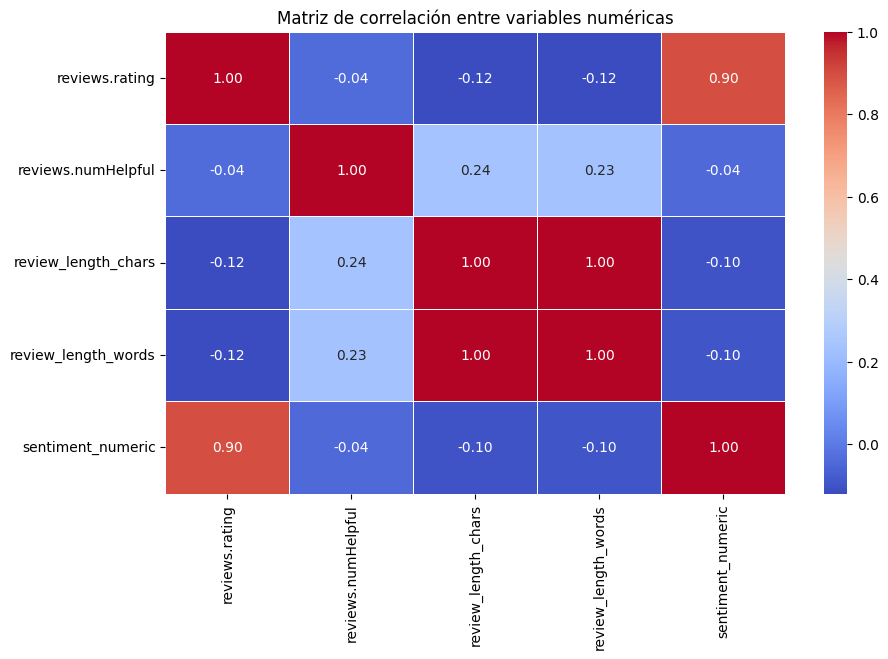

In [53]:
#Heatmap de correlación

plt.figure(figsize=(10, 6))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")
plt.show()

,reviews.rating,reviews.numHelpful,review_length_chars,review_length_words,sentiment_numeric
reviews.rating,1.000,-0.033,-0.154,-0.158,0.643
reviews.numHelpful,-0.033,1.000,0.199,0.194,-0.034
review_length_chars,-0.154,0.199,1.000,0.990,-0.109
review_length_words,-0.158,0.194,0.990,1.000,-0.107
sentiment_numeric,0.643,-0.034,-0.109,-0.107,1.000


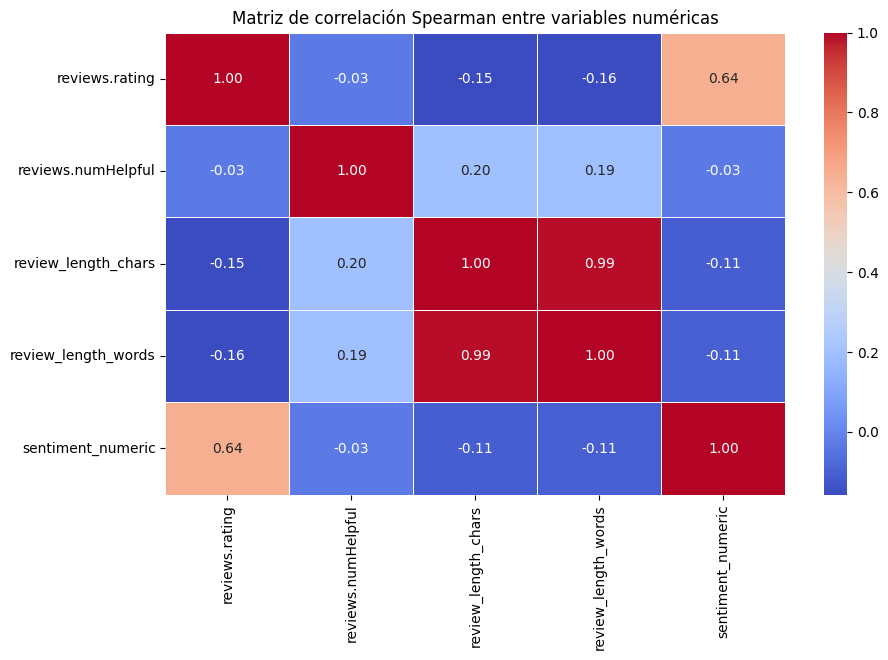

In [54]:
#Heatmap usando Spearman

#Como algunas variables están muy sesgadas y no tienen distribución normal, también es recomendable usar Spearman, que mide relaciones monotónicas y es menos sensible a outliers.

matriz_spearman = df_corr.corr(method="spearman")

display(matriz_spearman.round(3))

plt.figure(figsize=(10, 6))

sns.heatmap(
    matriz_spearman,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación Spearman entre variables numéricas")
plt.show()

In [55]:
#Identificar relaciones fuertes automáticamente

# Convertir matriz de correlación a formato largo
corr_pairs = matriz_correlacion.unstack().reset_index()
corr_pairs.columns = ["Variable 1", "Variable 2", "Correlación"]

# Eliminar autocorrelaciones
corr_pairs = corr_pairs[corr_pairs["Variable 1"] != corr_pairs["Variable 2"]]

# Evitar duplicados A-B y B-A
corr_pairs["par_ordenado"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["Variable 1"], row["Variable 2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates("par_ordenado").drop(columns="par_ordenado")

# Valor absoluto para ordenar
corr_pairs["Correlación absoluta"] = corr_pairs["Correlación"].abs()

# Ordenar de mayor a menor
corr_pairs = corr_pairs.sort_values(by="Correlación absoluta", ascending=False)

display(corr_pairs.round(3))

,Variable 1,Variable 2,Correlación,Correlación absoluta
13,review_length_chars,review_length_words,0.997,0.997
4,reviews.rating,sentiment_numeric,0.898,0.898
7,reviews.numHelpful,review_length_chars,0.237,0.237
8,reviews.numHelpful,review_length_words,0.233,0.233
2,reviews.rating,review_length_chars,-0.120,0.120
3,reviews.rating,review_length_words,-0.120,0.120
14,review_length_chars,sentiment_numeric,-0.098,0.098
19,review_length_words,sentiment_numeric,-0.097,0.097
9,reviews.numHelpful,sentiment_numeric,-0.042,0.042
1,reviews.rating,reviews.numHelpful,-0.041,0.041


In [56]:
#Clasificar fuerza de correlación

def clasificar_correlacion(valor):
    abs_val = abs(valor)

    if abs_val >= 0.80:
        return "Muy fuerte"
    elif abs_val >= 0.60:
        return "Fuerte"
    elif abs_val >= 0.40:
        return "Moderada"
    elif abs_val >= 0.20:
        return "Débil"
    else:
        return "Muy débil o nula"

corr_pairs["Interpretación"] = corr_pairs["Correlación"].apply(clasificar_correlacion)

display(corr_pairs.round(3))

,Variable 1,Variable 2,Correlación,Correlación absoluta,Interpretación
13,review_length_chars,review_length_words,0.997,0.997,Muy fuerte
4,reviews.rating,sentiment_numeric,0.898,0.898,Muy fuerte
7,reviews.numHelpful,review_length_chars,0.237,0.237,Débil
8,reviews.numHelpful,review_length_words,0.233,0.233,Débil
2,reviews.rating,review_length_chars,-0.120,0.120,Muy débil o nula
3,reviews.rating,review_length_words,-0.120,0.120,Muy débil o nula
14,review_length_chars,sentiment_numeric,-0.098,0.098,Muy débil o nula
19,review_length_words,sentiment_numeric,-0.097,0.097,Muy débil o nula
9,reviews.numHelpful,sentiment_numeric,-0.042,0.042,Muy débil o nula
1,reviews.rating,reviews.numHelpful,-0.041,0.041,Muy débil o nula


In [57]:
#Calcular VIF para multicolinealidad

#El VIF permite detectar multicolinealidad entre variables numéricas.


from statsmodels.stats.outliers_influence import variance_inflation_factor

# Seleccionar variables predictoras numéricas
# No se incluye sentiment_numeric porque es el target codificado
variables_vif = [
    "reviews.rating",
    "reviews.numHelpful",
    "review_length_chars",
    "review_length_words"
]

variables_vif = [col for col in variables_vif if col in df.columns]

# Crear dataframe sin nulos
df_vif = df[variables_vif].dropna()

# Calcular VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = df_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(df_vif.values, i)
    for i in range(df_vif.shape[1])
]

display(vif_data.round(2))

,Variable,VIF
0,reviews.rating,1.58
1,reviews.numHelpful,1.07
2,review_length_chars,308.27
3,review_length_words,312.36


In [58]:
#Interpretar VIF

def interpretar_vif(vif):
    if vif >= 10:
        return "Multicolinealidad alta"
    elif vif >= 5:
        return "Multicolinealidad moderada"
    else:
        return "Sin multicolinealidad relevante"

vif_data["Interpretación"] = vif_data["VIF"].apply(interpretar_vif)

display(vif_data.round(2))

,Variable,VIF,Interpretación
0,reviews.rating,1.58,Sin multicolinealidad relevante
1,reviews.numHelpful,1.07,Sin multicolinealidad relevante
2,review_length_chars,308.27,Multicolinealidad alta
3,review_length_words,312.36,Multicolinealidad alta


**Análisis**

1. Matriz de correlación

La matriz de correlación permite observar la relación lineal entre las variables numéricas del dataset. En este proyecto, se analizan variables como:

reviews.rating
reviews.numHelpful
review_length_chars
review_length_words
sentiment_numeric

El objetivo es identificar si existen relaciones fuertes entre variables que puedan generar redundancia o afectar la interpretación del modelo.

2. Relación entre reviews.rating y sentiment_numeric

Se espera encontrar una correlación muy alta entre reviews.rating y sentiment_numeric, ya que la variable objetivo sentiment fue construida directamente a partir de la calificación.

Esto no representa un hallazgo predictivo real, sino una consecuencia de la definición del target.

Interpretación

reviews.rating no debe utilizarse como variable predictora en el modelo final porque produciría data leakage, es decir, una fuga de información. El modelo estaría aprendiendo directamente de la variable que se usó para crear la etiqueta.

En el modelo final, reviews.rating debe usarse solo para construir el target, no como entrada predictiva.

3. Relación entre review_length_chars y review_length_words

Se espera una correlación muy fuerte entre review_length_chars y review_length_words.

Esto ocurre porque ambas variables miden prácticamente el mismo concepto: la extensión de la reseña.

review_length_chars mide cantidad de caracteres.
review_length_words mide cantidad de palabras.
Interpretación

Estas dos variables son redundantes. Si se decide usar longitud de reseña como variable adicional, no es necesario incluir ambas. Se recomienda conservar review_length_words, porque es más interpretable desde el punto de vista del análisis textual.

4. Relación entre reviews.numHelpful y otras variables

La variable reviews.numHelpful puede tener una correlación baja o moderada con la longitud de la reseña.

Esto tendría sentido si las reseñas más largas reciben más votos de utilidad porque contienen más detalle sobre la experiencia del cliente.

Sin embargo, esta variable tiene muchos valores en cero, valores nulos y outliers extremos, por lo que cualquier correlación debe interpretarse con cautela.

Interpretación

reviews.numHelpful puede usarse para análisis exploratorio, pero no necesariamente como variable principal del modelo. Su distribución altamente sesgada puede afectar la estabilidad del análisis.

5. Variables redundantes

Una variable puede considerarse redundante cuando tiene una correlación muy alta con otra variable, usualmente mayor a 0.80.

En este proyecto, la principal redundancia esperada es:

| Variables                                     | Razón                                     |
| --------------------------------------------- | ----------------------------------------- |
| `review_length_chars` y `review_length_words` | Ambas miden longitud de reseña.           |
| `reviews.rating` y `sentiment_numeric`        | El target fue construido desde el rating. |


**Desición**

Para evitar redundancia:

* no usar reviews.rating como predictor;
* no usar sentiment_numeric como predictor;
* usar solo una variable de longitud si se desea incluirla, preferiblemente review_length_words

##**6. Outliers**



In [59]:
#Preparar variables numéricas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Crear variables de longitud de texto
df["review_length_chars"] = df["reviews.text"].astype(str).apply(len)
df["review_length_words"] = df["reviews.text"].astype(str).apply(lambda x: len(x.split()))

# Convertir reviews.numHelpful a numérica
df["reviews.numHelpful"] = pd.to_numeric(df["reviews.numHelpful"], errors="coerce")

# Variables numéricas a analizar
variables_numericas = [
    "reviews.rating",
    "reviews.numHelpful",
    "review_length_chars",
    "review_length_words"
]

variables_numericas = [col for col in variables_numericas if col in df.columns]

print("Variables numéricas seleccionadas:")
print(variables_numericas)

Variables numéricas seleccionadas:
['reviews.rating', 'reviews.numHelpful', 'review_length_chars', 'review_length_words']


In [60]:
#Detectar outliers con método IQR

#El método IQR usa el rango intercuartílico para detectar valores extremos.

outliers_iqr_resumen = []

for col in variables_numericas:
    serie = df[col].dropna()

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]

    outliers_iqr_resumen.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Cantidad de outliers": len(outliers),
        "Porcentaje de outliers": round((len(outliers) / len(serie)) * 100, 2),
        "Mínimo outlier": outliers.min() if len(outliers) > 0 else np.nan,
        "Máximo outlier": outliers.max() if len(outliers) > 0 else np.nan
    })

outliers_iqr_resumen = pd.DataFrame(outliers_iqr_resumen)

display(outliers_iqr_resumen)

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad de outliers,Porcentaje de outliers,Mínimo outlier,Máximo outlier
0,reviews.rating,4.0,5.0,1.0,2.5,6.5,1581,5.58,1.0,2.0
1,reviews.numHelpful,0.0,0.0,0.0,0.0,0.0,1237,7.68,1.0,621.0
2,review_length_chars,54.0,162.0,108.0,-108.0,324.0,2286,8.07,325.0,8351.0
3,review_length_words,10.0,31.0,21.0,-21.5,62.5,2162,7.63,63.0,1539.0


In [ ]:
#Ver registros outliers por variable con IQR

outliers_iqr_dict = {}

for col in variables_numericas:
    serie = df[col].dropna()

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    condicion_outlier = (df[col] < limite_inferior) | (df[col] > limite_superior)

    outliers_iqr_dict[col] = df[condicion_outlier]

    print(f"\nVariable: {col}")
    print(f"Cantidad de outliers detectados por IQR: {outliers_iqr_dict[col].shape[0]}")

    display(
        outliers_iqr_dict[col][
            ["name", "reviews.rating", "reviews.numHelpful", "review_length_words", "reviews.text"]
        ].head(10)
    )

In [61]:
#Detectar outliers con Z-score

#El Z-score mide cuántas desviaciones estándar se aleja un valor de la media. Usualmente se considera outlier si |Z-score| > 3.


from scipy.stats import zscore

outliers_zscore_resumen = []

for col in variables_numericas:
    serie = df[col].dropna()

    z_scores = np.abs(zscore(serie))
    outliers = serie[z_scores > 3]

    outliers_zscore_resumen.append({
        "Variable": col,
        "Cantidad de outliers Z-score": len(outliers),
        "Porcentaje de outliers Z-score": round((len(outliers) / len(serie)) * 100, 2),
        "Mínimo outlier": outliers.min() if len(outliers) > 0 else np.nan,
        "Máximo outlier": outliers.max() if len(outliers) > 0 else np.nan
    })

outliers_zscore_resumen = pd.DataFrame(outliers_zscore_resumen)

display(outliers_zscore_resumen)

,Variable,Cantidad de outliers Z-score,Porcentaje de outliers Z-score,Mínimo outlier,Máximo outlier
0,reviews.rating,965,3.41,1.0,1.0
1,reviews.numHelpful,40,0.25,29.0,621.0
2,review_length_chars,340,1.20,739.0,8351.0
3,review_length_words,351,1.24,138.0,1539.0


In [62]:
#Ver registros outliers por Z-score

outliers_zscore_dict = {}

for col in variables_numericas:
    serie = df[col].dropna()

    z_scores = pd.Series(
        np.abs(zscore(serie)),
        index=serie.index
    )

    indices_outliers = z_scores[z_scores > 3].index

    outliers_zscore_dict[col] = df.loc[indices_outliers]

    print(f"\nVariable: {col}")
    print(f"Cantidad de outliers detectados por Z-score: {outliers_zscore_dict[col].shape[0]}")

    display(
        outliers_zscore_dict[col][
            ["name", "reviews.rating", "reviews.numHelpful", "review_length_words", "reviews.text"]
        ].head(10)
    )


Variable: reviews.rating
Cantidad de outliers detectados por Z-score: 965


,name,reviews.rating,reviews.numHelpful,review_length_words,reviews.text
16,AmazonBasics AAA Performance Alkaline Batterie...,1,NaN,19,I don't know if I would buy thus brand again s...
24,AmazonBasics AAA Performance Alkaline Batterie...,1,NaN,12,These do not last long at all very cheap batte...
39,AmazonBasics AAA Performance Alkaline Batterie...,1,NaN,64,These batteries are horrible. We depend on AA ...
43,AmazonBasics AAA Performance Alkaline Batterie...,1,NaN,35,First time I bought these they worked well and...
45,AmazonBasics AAA Performance Alkaline Batterie...,1,NaN,14,These batteries don't last even in a simple di...
47,AmazonBasics AAA Performance Alkaline Batterie...,1,NaN,11,"Date on the back of these were 1992. Yeah, 199..."
64,AmazonBasics AAA Performance Alkaline Batterie...,1,NaN,9,Battery storage life only lasted 8 months (sto...
114,AmazonBasics AAA Performance Alkaline Batterie...,1,NaN,16,During my first recharging they were leaking a...
175,AmazonBasics AAA Performance Alkaline Batterie...,1,NaN,6,These don't last long at all.
183,AmazonBasics AAA Performance Alkaline Batterie...,1,NaN,25,Lasted about a week in my electric toothbrush....



Variable: reviews.numHelpful
Cantidad de outliers detectados por Z-score: 40


,name,reviews.rating,reviews.numHelpful,review_length_words,reviews.text
12206,Kindle PowerFast International Charging Kit (f...,5,40.0,135,I travel internationally at least once a year ...
12210,Kindle PowerFast International Charging Kit (f...,5,238.0,246,"I do a lot of international travelling, so I h..."
12764,Amazon Tap Smart Assistant Alexaenabled (black...,5,434.0,197,It was just a few weeks ago that I was bemoani...
12859,Oem Amazon Kindle Power Usb Adapter Wall Trave...,1,621.0,31,Is Amazon kidding me They want me to pay 19.99...
12862,Oem Amazon Kindle Power Usb Adapter Wall Trave...,1,220.0,218,"No reason. This product is described as 5W, 1 ..."
12936,"Kindle Voyage E-reader, 6 High-Resolution Disp...",5,39.0,72,Having owned each of the previous Kindle reade...
12986,"Kindle Voyage E-reader, 6 High-Resolution Disp...",4,72.0,220,I am a big fan of e-readers. I prefer the e-in...
13665,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5,45.0,80,"I bought 2, 1 for each kid. Easy to set up and..."
14702,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4,65.0,174,I bought my Fire HD8 as an alternative to carr...
14902,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4,68.0,211,I am a power user; there's no other way of put...



Variable: review_length_chars
Cantidad de outliers detectados por Z-score: 340


,name,reviews.rating,reviews.numHelpful,review_length_words,reviews.text
63,AmazonBasics AAA Performance Alkaline Batterie...,4,NaN,819,AmazonBasics batteries are quite good in terms...
110,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,212,I've been buying AAA alkaline batteries in pac...
111,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,135,Thats a whole lot of batteries! I ordered the ...
185,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,138,You get what you pay for in life bht for the l...
368,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,126,I bought these batteries being skeptical about...
411,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,143,I'm not going to go into a great deal of detai...
416,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,237,I love these batteries. I am so happy that I b...
439,AmazonBasics AAA Performance Alkaline Batterie...,4,NaN,144,"Well, these are basic, average, ordinary non-r..."
466,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,128,Using my el cheapo multimeter (Fluke was at wo...
610,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,161,"I prefer purchasing my batteries in bulk, so t..."



Variable: review_length_words
Cantidad de outliers detectados por Z-score: 351


,name,reviews.rating,reviews.numHelpful,review_length_words,reviews.text
63,AmazonBasics AAA Performance Alkaline Batterie...,4,NaN,819,AmazonBasics batteries are quite good in terms...
110,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,212,I've been buying AAA alkaline batteries in pac...
185,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,138,You get what you pay for in life bht for the l...
411,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,143,I'm not going to go into a great deal of detai...
416,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,237,I love these batteries. I am so happy that I b...
439,AmazonBasics AAA Performance Alkaline Batterie...,4,NaN,144,"Well, these are basic, average, ordinary non-r..."
610,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,161,"I prefer purchasing my batteries in bulk, so t..."
611,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,168,These Amazon AA batteries are better than othe...
666,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,169,What I found was that in our Wii controllers a...
702,AmazonBasics AAA Performance Alkaline Batterie...,5,NaN,176,I have quickly become a fan of Amazon Basics p...


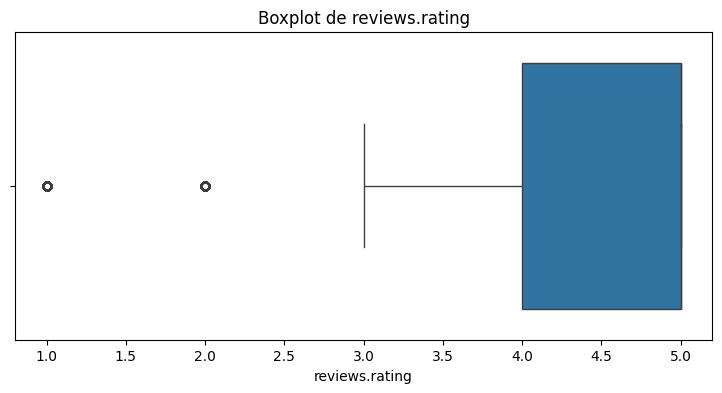

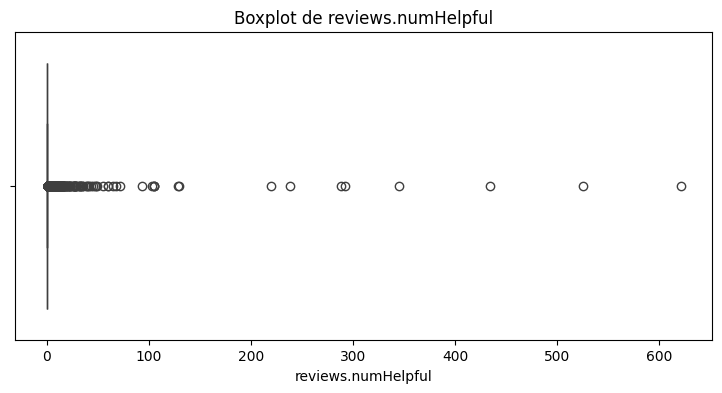

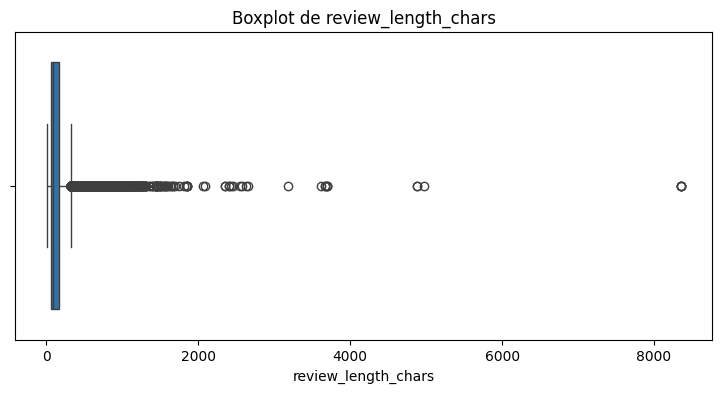

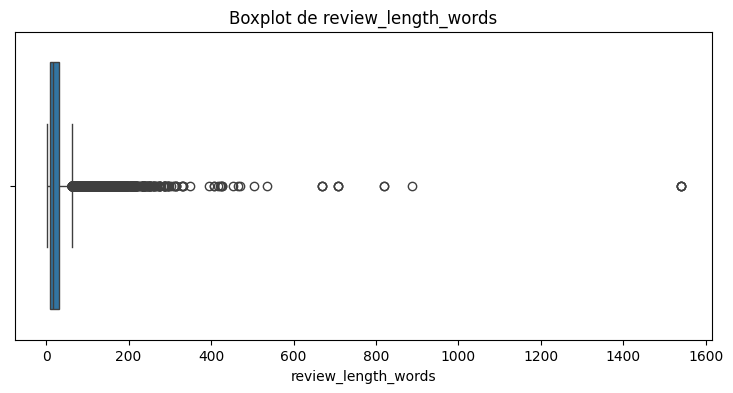

In [63]:
#Boxplots para visualizar outliers

for col in variables_numericas:
    plt.figure(figsize=(9, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

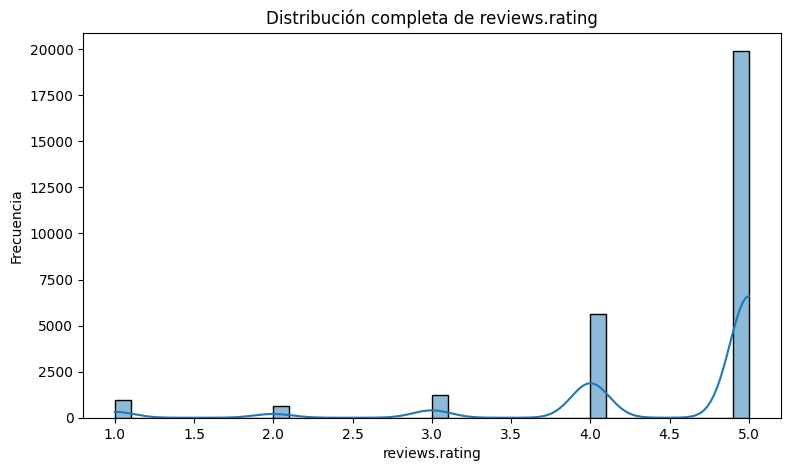

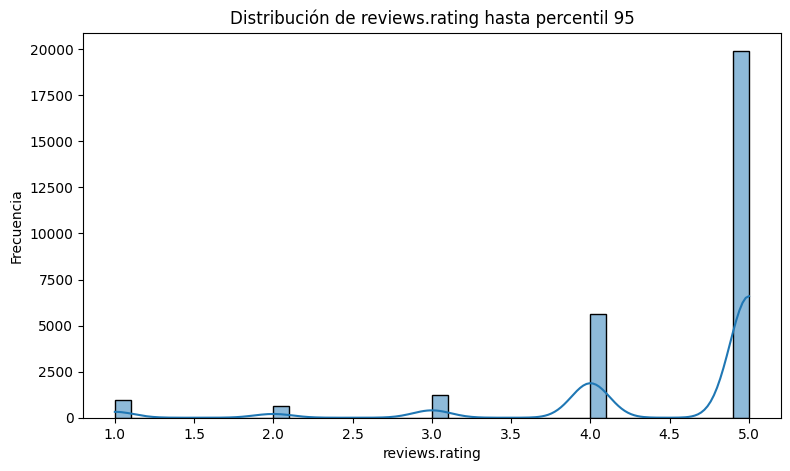

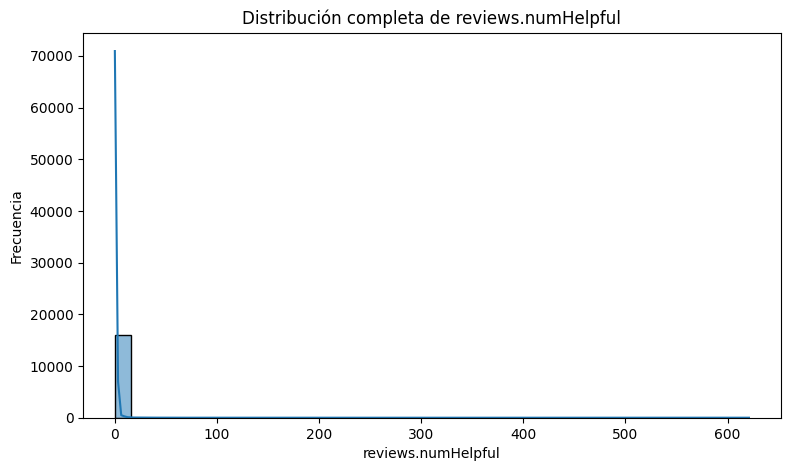

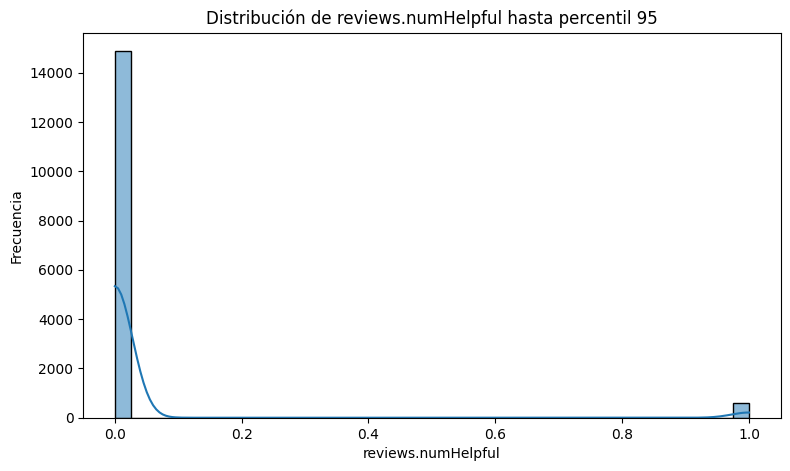

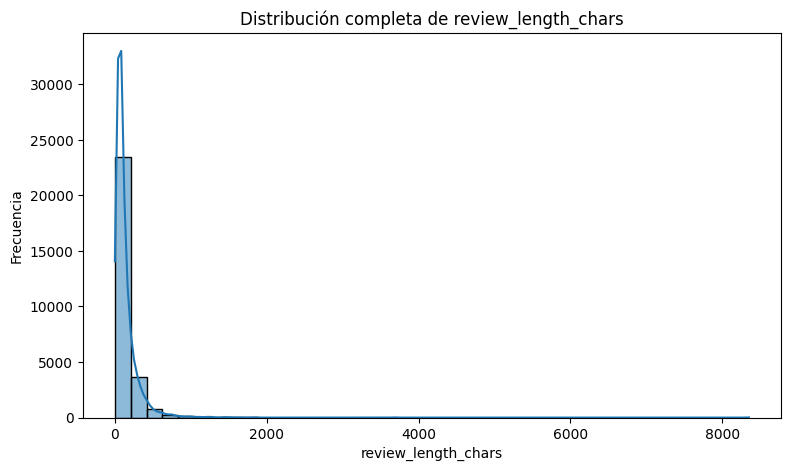

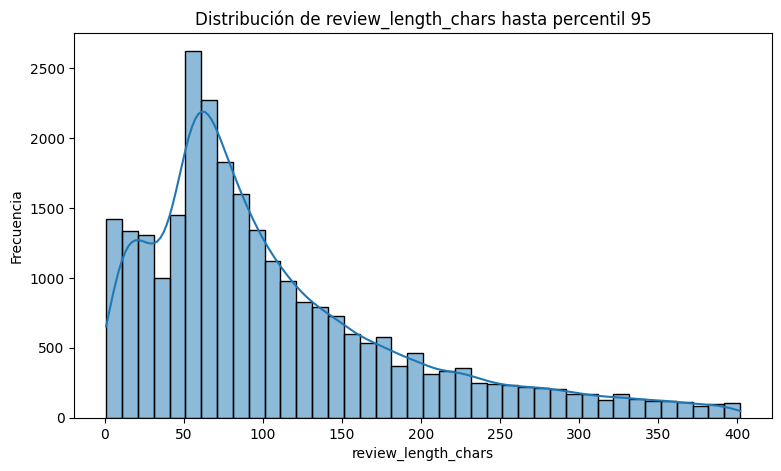

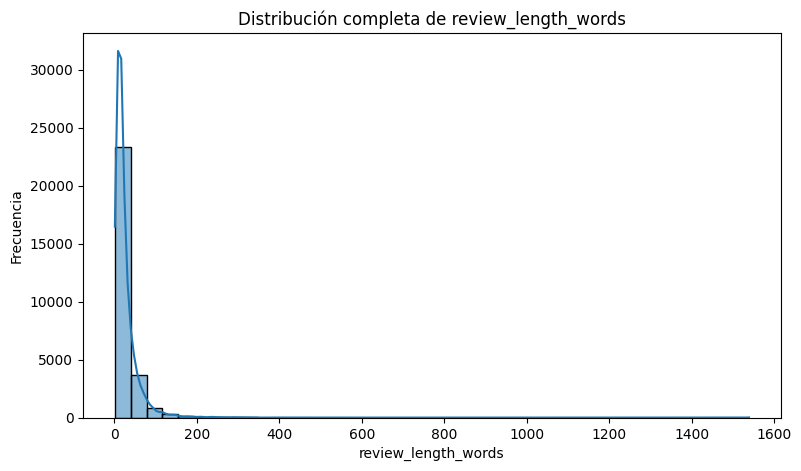

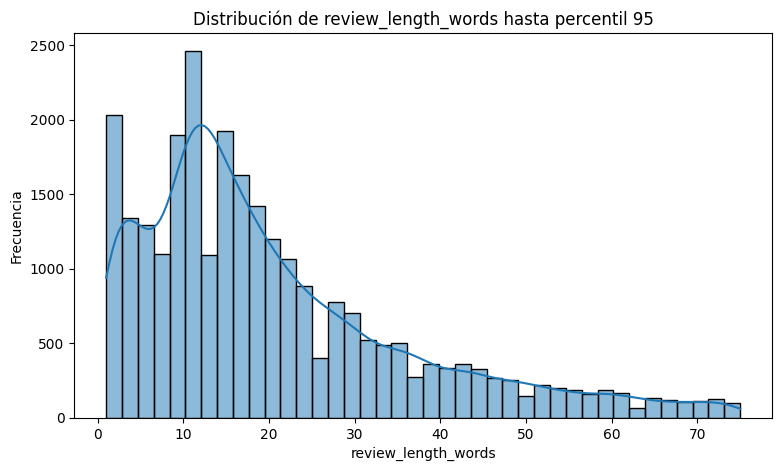

In [64]:
#Histogramas con y sin outliers

for col in variables_numericas:
    plt.figure(figsize=(9, 5))

    sns.histplot(df[col].dropna(), bins=40, kde=True)

    plt.title(f"Distribución completa de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

    p95 = df[col].dropna().quantile(0.95)

    plt.figure(figsize=(9, 5))

    sns.histplot(df[df[col] <= p95][col].dropna(), bins=40, kde=True)

    plt.title(f"Distribución de {col} hasta percentil 95")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

In [65]:
#Crear una columna que marque si una fila tiene outliers

df["tiene_outlier_iqr"] = False

for col in variables_numericas:
    serie = df[col].dropna()

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    condicion_outlier = (df[col] < limite_inferior) | (df[col] > limite_superior)

    df.loc[condicion_outlier, "tiene_outlier_iqr"] = True

print("Cantidad de filas con al menos un outlier:", df["tiene_outlier_iqr"].sum())
print("Porcentaje de filas con al menos un outlier:", round(df["tiene_outlier_iqr"].mean() * 100, 2), "%")

Cantidad de filas con al menos un outlier: 4394
Porcentaje de filas con al menos un outlier: 15.51 %


In [66]:
#Alternativa: winsorización

#En lugar de eliminar outliers, puede limitar los valores extremos al percentil 95 o 99. Esto es útil para variables como reviews.numHelpful o longitud de reseñas.

df_winsorizado = df.copy()

variables_a_winsorizar = [
    "reviews.numHelpful",
    "review_length_chars",
    "review_length_words"
]

for col in variables_a_winsorizar:
    if col in df_winsorizado.columns:
        p01 = df_winsorizado[col].quantile(0.01)
        p99 = df_winsorizado[col].quantile(0.99)

        df_winsorizado[col + "_winsorized"] = df_winsorizado[col].clip(
            lower=p01,
            upper=p99
        )

display(
    df_winsorizado[
        [
            "reviews.numHelpful",
            "reviews.numHelpful_winsorized",
            "review_length_words",
            "review_length_words_winsorized"
        ]
    ].head()
)

,reviews.numHelpful,reviews.numHelpful_winsorized,review_length_words,review_length_words_winsorized
0,NaN,NaN,31,31
1,NaN,NaN,13,13
2,NaN,NaN,12,12
3,NaN,NaN,14,14
4,NaN,NaN,10,10


**Analisis**

1. Variables analizadas

Para el análisis de outliers se consideraron las principales variables numéricas del dataset:

| Variable              | Descripción                                               |
| --------------------- | --------------------------------------------------------- |
| `reviews.rating`      | Calificación otorgada por el cliente, de 1 a 5 estrellas. |
| `reviews.numHelpful`  | Número de votos de utilidad recibidos por la reseña.      |
| `review_length_chars` | Longitud de la reseña en caracteres.                      |
| `review_length_words` | Longitud de la reseña en palabras.                        |


Estas variables permiten identificar patrones extremos relacionados con calificación, utilidad de la reseña y extensión del comentario.

2. Posibles causas de outliers
reviews.rating

En esta variable, los valores posibles van de 1 a 5. Técnicamente, valores como 1 o 2 pueden aparecer como outliers por el método IQR debido a que la mayoría de las reseñas están concentradas en 4 y 5 estrellas.

Sin embargo, estos valores no son errores. Representan reseñas negativas reales.

Causa probable: concentración alta de reseñas positivas y baja proporción de reseñas negativas.

Decisión recomendada: no eliminar outliers en reviews.rating, porque las calificaciones bajas son esenciales para construir la clase negativa del target.

reviews.numHelpful

Esta variable puede tener outliers extremos, como reseñas con cientos de votos útiles. Esto ocurre porque algunas reseñas son mucho más visibles, antiguas o relevantes para otros compradores.

Causas posibles:

reseñas publicadas hace más tiempo;
reseñas muy detalladas;
reseñas negativas consideradas útiles;
productos con alto volumen de compradores;
comentarios destacados por la plataforma.

Decisión: no eliminar automáticamente. Para visualizaciones, se recomienda limitar al percentil 95 o 99. Para modelado, esta variable no debería ser predictor principal.

review_length_chars

Algunas reseñas pueden tener una cantidad de caracteres mucho mayor que la mayoría. Esto indica comentarios largos, detallados o repetitivos.

Causas posibles:

reseñas explicativas;
clientes describiendo problemas técnicos;
comparaciones extensas;
textos copiados o duplicados;
comentarios con mucho detalle sobre uso del producto.

Decisión: revisar los casos extremos. No eliminarlos automáticamente, porque pueden contener información valiosa para el análisis de sentimiento.

review_length_words

Esta variable muestra outliers similares a review_length_chars, ya que ambas miden la extensión de la reseña.

Causas posibles:

reseñas largas con experiencias detalladas;
explicaciones de problemas;
comentarios técnicos;
reseñas con múltiples aspectos positivos y negativos.

Decisión: conservar en el dataset, pero analizar si las reseñas extremadamente largas afectan el modelo. Si se usan variables de longitud, puede aplicarse winsorización.

3. ¿Deben eliminarse los outliers?

No se recomienda eliminar outliers de forma automática en este proyecto.

La razón principal es que los outliers pueden representar comportamientos reales e importantes del consumidor. Por ejemplo:

una reseña con calificación 1 puede representar una experiencia negativa crítica;
una reseña con muchos votos útiles puede representar una opinión influyente;
una reseña muy larga puede contener información detallada sobre problemas o ventajas del producto.

Eliminar estos registros podría reducir la capacidad del análisis para identificar casos relevantes de insatisfacción.

#**Balance del target**


In [67]:
#Crear la variable objetivo sentiment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Crear target a partir de reviews.rating
def clasificar_sentimiento(rating):
    if rating in [1, 2]:
        return "Negativo"
    elif rating == 3:
        return "Neutral"
    elif rating in [4, 5]:
        return "Positivo"
    else:
        return np.nan

df["sentiment"] = df["reviews.rating"].apply(clasificar_sentimiento)

# Verificar primeras filas
df[["reviews.rating", "sentiment"]].head()

,reviews.rating,sentiment
0,3,Neutral
1,4,Positivo
2,5,Positivo
3,5,Positivo
4,5,Positivo


In [68]:
#Distribución de clases

# Conteo absoluto de cada clase
distribucion_clases = df["sentiment"].value_counts()

print("Distribución de clases:")
print(distribucion_clases)

Distribución de clases:
sentiment
Positivo    25545
Negativo     1581
Neutral      1206
Name: count, dtype: int64


In [69]:
#Porcentaje de cada clase

porcentaje_clases = df["sentiment"].value_counts(normalize=True) * 100

print("Porcentaje de clases:")
print(porcentaje_clases.round(2))

Porcentaje de clases:
sentiment
Positivo    90.16
Negativo     5.58
Neutral      4.26
Name: proportion, dtype: float64


In [70]:
#Tabla resumen del balance del target

balance_target = pd.DataFrame({
    "Cantidad": distribucion_clases,
    "Porcentaje": porcentaje_clases.round(2)
})

display(balance_target)

,Cantidad,Porcentaje
sentiment,,
Positivo,25545,90.16
Negativo,1581,5.58
Neutral,1206,4.26


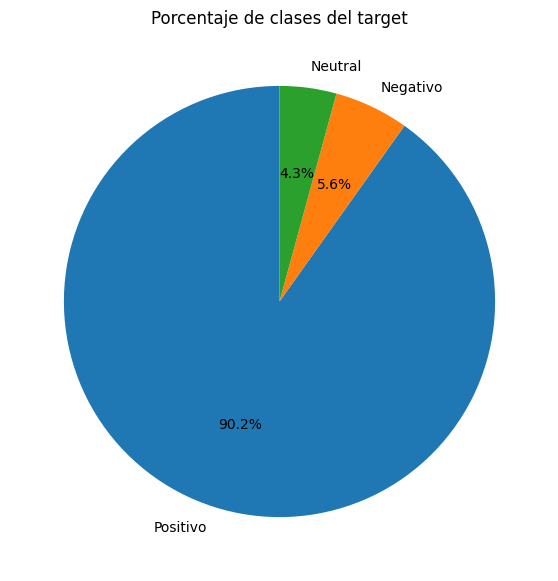

In [71]:
#Gráfico de pastel: proporción de clases

plt.figure(figsize=(7, 7))

df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Porcentaje de clases del target")
plt.ylabel("")
plt.show()

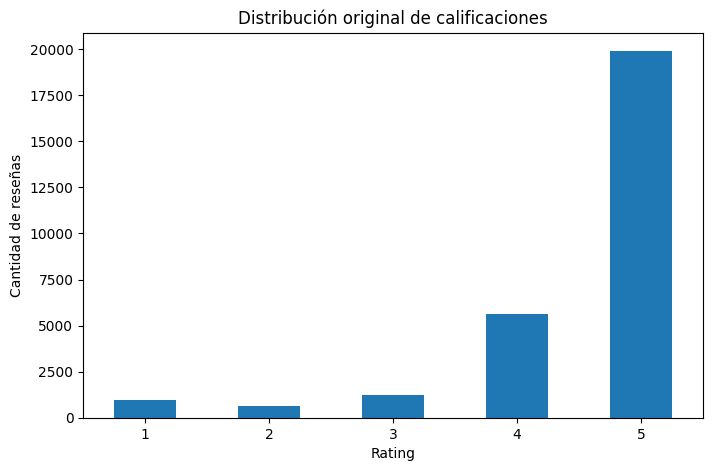

In [72]:
#Comparación con reviews.rating

plt.figure(figsize=(8, 5))

df["reviews.rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribución original de calificaciones")
plt.xlabel("Rating")
plt.ylabel("Cantidad de reseñas")
plt.xticks(rotation=0)
plt.show()

In [73]:
#Medir riesgo de desbalance automáticamente

# Calcular clase mayoritaria y minoritaria
clase_mayoritaria = distribucion_clases.idxmax()
cantidad_mayoritaria = distribucion_clases.max()

clase_minoritaria = distribucion_clases.idxmin()
cantidad_minoritaria = distribucion_clases.min()

ratio_desbalance = cantidad_mayoritaria / cantidad_minoritaria

print("Clase mayoritaria:", clase_mayoritaria)
print("Cantidad clase mayoritaria:", cantidad_mayoritaria)

print("Clase minoritaria:", clase_minoritaria)
print("Cantidad clase minoritaria:", cantidad_minoritaria)

print("Ratio de desbalance:", round(ratio_desbalance, 2))

Clase mayoritaria: Positivo
Cantidad clase mayoritaria: 25545
Clase minoritaria: Neutral
Cantidad clase minoritaria: 1206
Ratio de desbalance: 21.18


In [74]:
#Interpretación automática del desbalance

def interpretar_desbalance(ratio):
    if ratio < 2:
        return "Balance aceptable"
    elif ratio < 5:
        return "Desbalance moderado"
    elif ratio < 10:
        return "Desbalance alto"
    else:
        return "Desbalance severo"

nivel_desbalance = interpretar_desbalance(ratio_desbalance)

print("Nivel de desbalance:", nivel_desbalance)

Nivel de desbalance: Desbalance severo


**Analisis**

Dado que en el análisis exploratorio se observó que la mayoría de las calificaciones son de 4 y 5 estrellas, es esperable que la clase Positivo sea la clase dominante.

Esto significa que el dataset probablemente estará desbalanceado hacia reseñas positivas.

2. Riesgo de desbalance

El principal riesgo es que el modelo aprenda a favorecer la clase mayoritaria.

Por ejemplo, si la mayoría de las reseñas son positivas, el modelo podría clasificar muchas reseñas como positivas y aun así obtener un accuracy alto. Sin embargo, esto no significa que el modelo sea bueno identificando reseñas negativas o neutrales.

Este riesgo es importante porque las reseñas negativas son las que más valor aportan para detectar problemas, inconformidades u oportunidades de mejora.

3. Cómo afecta el desbalance al modelo

El desbalance puede afectar el modelo de varias formas:

| Impacto                         | Explicación                                                                                                   |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------- |
| Alto accuracy engañoso          | El modelo puede parecer bueno porque predice bien la clase mayoritaria.                                       |
| Bajo recall en clase negativa   | Puede fallar al detectar reseñas negativas reales.                                                            |
| Bajo desempeño en clase neutral | Las reseñas neutrales pueden confundirse con positivas o negativas.                                           |
| Sesgo hacia lo positivo         | El modelo puede aprender que la mayoría de comentarios son positivos y clasificar excesivamente en esa clase. |
| Menor valor de negocio          | Si no detecta comentarios negativos, se pierden oportunidades de mejora.                                      |


**Métricas recomendadas ante desbalance**

Para este proyecto, las métricas más importantes serán:

| Métrica                 | Motivo                                                                          |
| ----------------------- | ------------------------------------------------------------------------------- |
| **F1-score macro**      | Evalúa todas las clases por igual, aunque una clase tenga más registros.        |
| **Recall por clase**    | Permite saber si el modelo detecta correctamente reseñas negativas y neutrales. |
| **Precision por clase** | Indica qué tan confiables son las predicciones de cada sentimiento.             |
| **Matriz de confusión** | Permite ver si las reseñas negativas se confunden con positivas.                |
| **Balanced accuracy**   | Mide el accuracy considerando el balance entre clases.                          |


**Posibles soluciones al desbalance**
1. Usar métricas adecuadas

La primera solución es evaluar el modelo con métricas que no favorezcan únicamente la clase mayoritaria.

Se recomienda usar:

F1-score macro,
recall por clase,
precision por clase,
matriz de confusión,
balanced accuracy.
2. Usar class_weight="balanced"

Algunos modelos, como Regresión Logística y Random Forest, permiten ajustar el peso de las clases.

Esto hace que el modelo penalice más los errores en clases minoritarias.

3. oversampling

El oversampling consiste en aumentar artificialmente la cantidad de ejemplos de las clases minoritarias.

Ejemplo:

duplicar reseñas negativas,
duplicar reseñas neutrales,
usar técnicas como RandomOverSampler.

4. Aplicar undersampling

El undersampling consiste en reducir la cantidad de ejemplos de la clase mayoritaria.

En este caso, se reducirían reseñas positivas para balancear el dataset.

5. Ajustar la definición del target

Si la clase neutral es muy pequeña, se puede considerar una clasificación binaria:

|  Rating | Sentimiento |
| ------: | ----------- |
| 1, 2, 3 | No positivo |
|    4, 5 | Positivo    |


##**9. Relaciones complejas**

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Crear target
def clasificar_sentimiento(rating):
    if rating in [1, 2]:
        return "Negativo"
    elif rating == 3:
        return "Neutral"
    elif rating in [4, 5]:
        return "Positivo"
    else:
        return np.nan

df["sentiment"] = df["reviews.rating"].apply(clasificar_sentimiento)

# Variables derivadas del texto
df["review_length_chars"] = df["reviews.text"].astype(str).apply(len)
df["review_length_words"] = df["reviews.text"].astype(str).apply(lambda x: len(x.split()))

# Asegurar variable numérica
df["reviews.numHelpful"] = pd.to_numeric(df["reviews.numHelpful"], errors="coerce")

# Dataset reducido para gráficos
vars_complex = [
    "reviews.rating",
    "reviews.numHelpful",
    "review_length_chars",
    "review_length_words",
    "sentiment"
]

df_complex = df[vars_complex].dropna()

# Para evitar gráficos pesados, tomar muestra
df_sample = df_complex.sample(
    n=min(3000, len(df_complex)),
    random_state=42
)

df_sample.head()

,reviews.rating,reviews.numHelpful,review_length_chars,review_length_words,sentiment
20582,5,0.0,161,35,Positivo
25264,5,0.0,104,22,Positivo
19173,3,0.0,130,24,Neutral
25012,5,0.0,89,18,Positivo
14525,5,0.0,58,9,Positivo


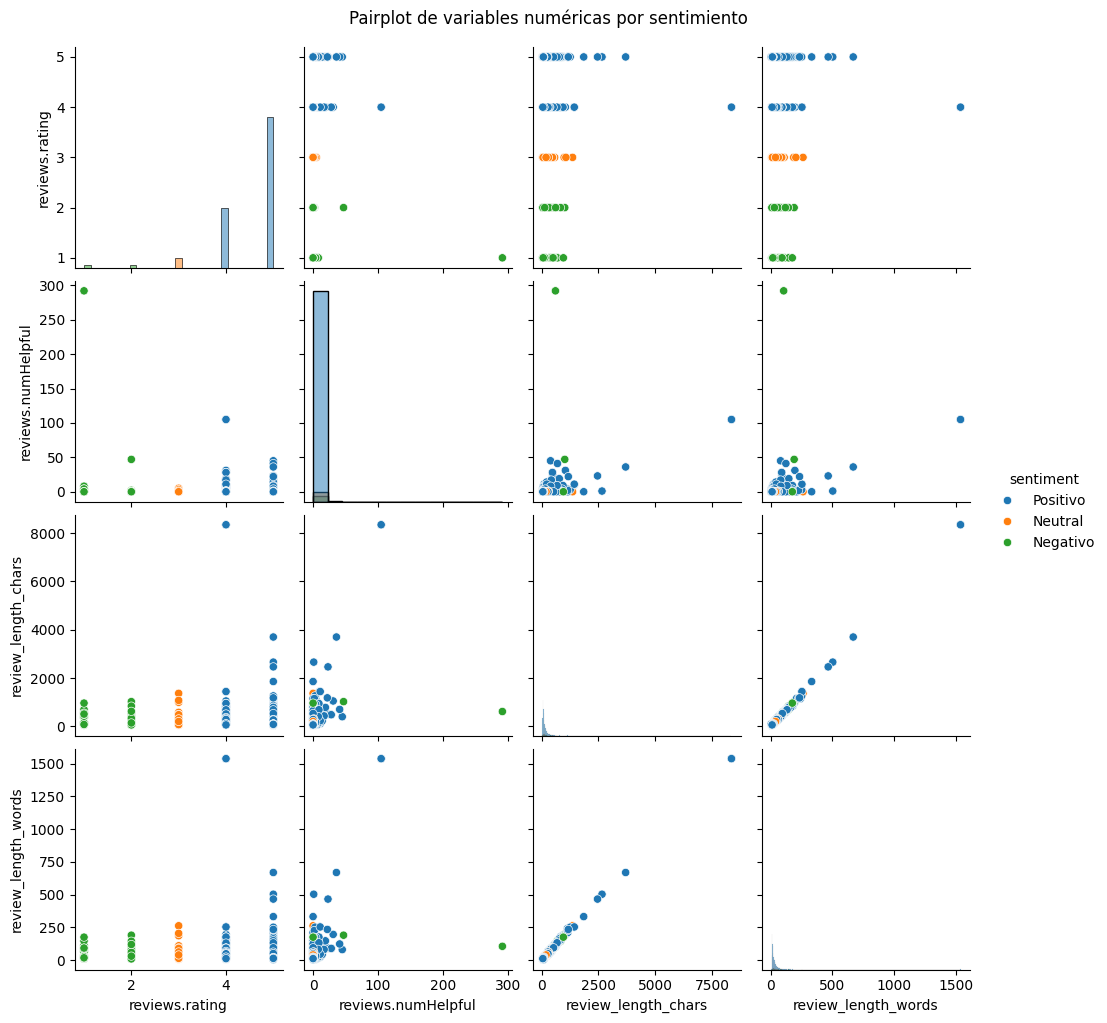

In [76]:
#Pairplot

sns.pairplot(
    df_sample,
    vars=[
        "reviews.rating",
        "reviews.numHelpful",
        "review_length_chars",
        "review_length_words"
    ],
    hue="sentiment",
    diag_kind="hist"
)

plt.suptitle("Pairplot de variables numéricas por sentimiento", y=1.02)
plt.show()

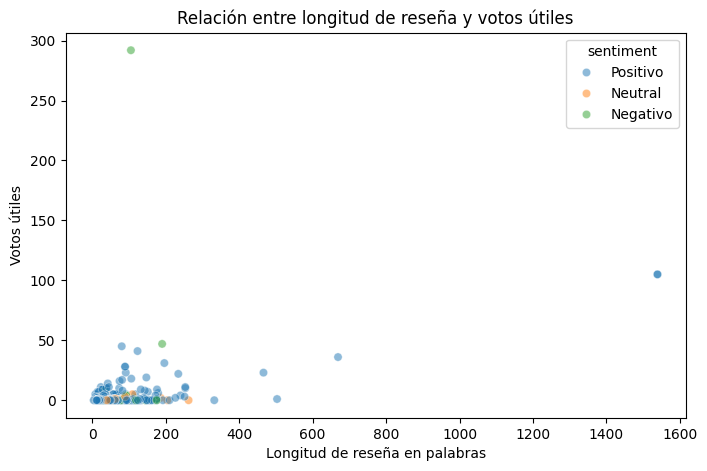

In [77]:
#Relaciones no lineales

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_sample,
    x="review_length_words",
    y="reviews.numHelpful",
    hue="sentiment",
    alpha=0.5
)

plt.title("Relación entre longitud de reseña y votos útiles")
plt.xlabel("Longitud de reseña en palabras")
plt.ylabel("Votos útiles")
plt.show()

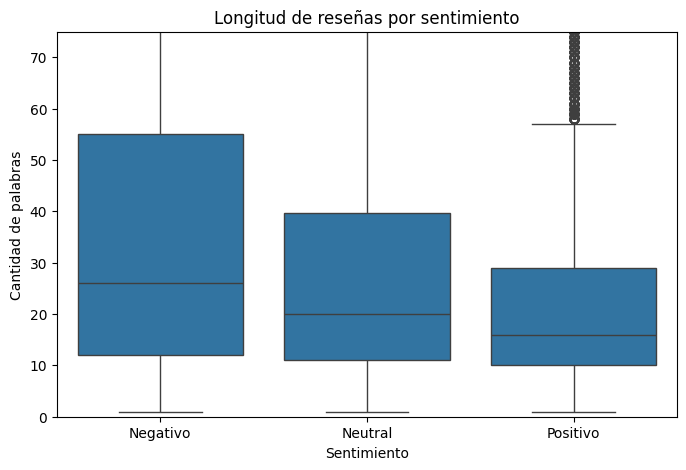

In [78]:
#Interacción entre longitud, utilidad y sentimiento

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="review_length_words",
    order=["Negativo", "Neutral", "Positivo"]
)

plt.ylim(0, df["review_length_words"].quantile(0.95))
plt.title("Longitud de reseñas por sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de palabras")
plt.show()

sentiment,Negativo,Neutral,Positivo
segmento_longitud,,,
Muy corta,4.07,3.69,92.23
Corta,4.22,3.97,91.81
Media,8.49,5.18,86.33
Larga,15.07,6.37,78.56


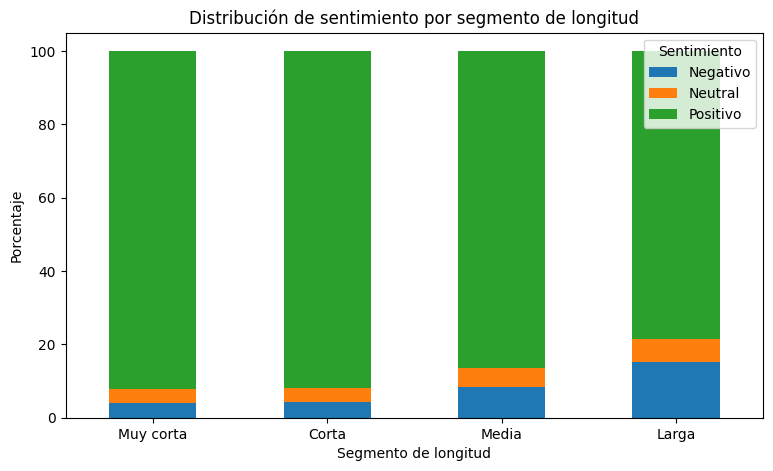

In [79]:
#Segmentación por longitud de reseña

df["segmento_longitud"] = pd.cut(
    df["review_length_words"],
    bins=[0, 10, 30, 75, np.inf],
    labels=["Muy corta", "Corta", "Media", "Larga"]
)

tabla_segmentos = pd.crosstab(
    df["segmento_longitud"],
    df["sentiment"],
    normalize="index"
) * 100

display(tabla_segmentos.round(2))

tabla_segmentos.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Distribución de sentimiento por segmento de longitud")
plt.xlabel("Segmento de longitud")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="Sentimiento")
plt.show()

sentiment,Negativo,Neutral,Positivo
primaryCategories,,,
Electronics,2.64,3.94,93.42
"Electronics,Media",2.16,1.62,96.22
Health & Beauty,9.49,4.42,86.08
"Office Supplies,Electronics",1.81,6.22,91.97
"Toys & Games,Electronics",3.22,5.55,91.23


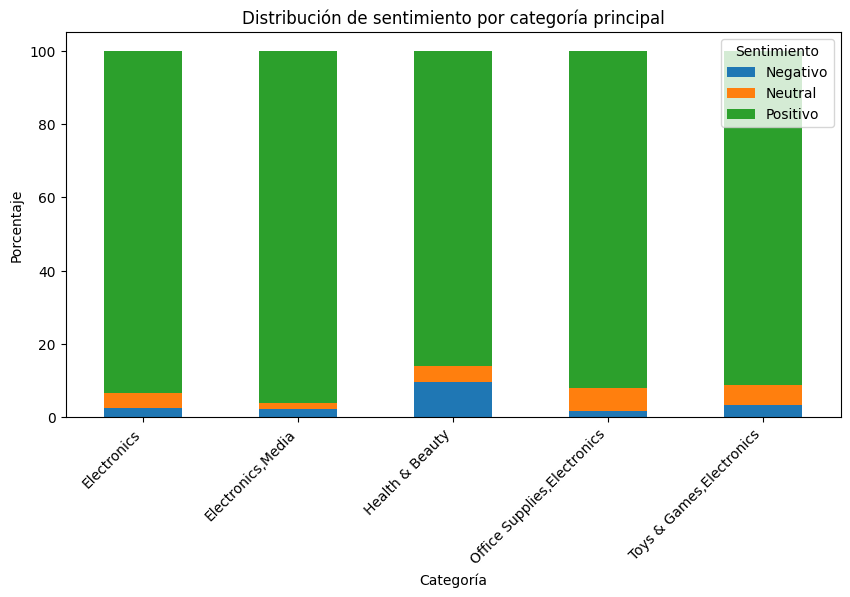

In [80]:
#Segmentación por categoría principal

top_categorias = df["primaryCategories"].value_counts().head(5).index

df_top_cat = df[df["primaryCategories"].isin(top_categorias)]

tabla_categoria = pd.crosstab(
    df_top_cat["primaryCategories"],
    df_top_cat["sentiment"],
    normalize="index"
) * 100

display(tabla_categoria.round(2))

tabla_categoria.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Distribución de sentimiento por categoría principal")
plt.xlabel("Categoría")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentimiento")
plt.show()

**Analisis**

El análisis de relaciones complejas permite observar posibles interacciones entre la longitud de las reseñas, los votos útiles, la calificación y el sentimiento. El pairplot ayuda a identificar si existen patrones visuales entre las variables numéricas y si las clases de sentimiento se separan claramente.

En este dataset, se espera observar que reviews.rating separa directamente las clases porque el target sentiment fue construido a partir de esa variable. Por esta razón, reviews.rating no debe usarse como predictor en el modelo final para evitar fuga de información.

Las variables review_length_words y review_length_chars pueden mostrar una relación no lineal con reviews.numHelpful. Es posible que reseñas más largas reciban más votos útiles, pero esta relación puede estar afectada por outliers. Por eso se recomienda analizar también versiones limitadas al percentil 95.

Las segmentaciones por longitud permiten identificar si las reseñas negativas tienden a ser más extensas que las positivas. Si esto ocurre, puede indicar que los clientes insatisfechos explican con más detalle sus problemas.

La segmentación por votos útiles permite explorar si las reseñas negativas reciben más atención de otros compradores. Esto puede apoyar la hipótesis de que los comentarios negativos tienen mayor valor informativo.

Finalmente, la segmentación por categoría principal permite identificar si algunas categorías concentran mayor proporción de sentimiento negativo, lo cual puede señalar oportunidades de mejora en productos específicos o áreas del negocio.

## **Ingeniería de características preliminar**

La ingeniería de características permitirá transformar las variables originales del dataset en nuevas variables más útiles para el análisis y el entrenamiento del modelo de Machine Learning.

**Variables propuestas**

| Tipo                       | Nueva variable                | Cómo se construye                                                    | Justificación                                                                              |
| -------------------------- | ----------------------------- | -------------------------------------------------------------------- | ------------------------------------------------------------------------------------------ |
| **Texto combinado**        | `review_full_text`            | Unir `reviews.title` + `reviews.text`                                | Puede mejorar el modelo porque el título resume la opinión y el texto aporta más contexto. |
| **Longitud del texto**     | `review_length_words`         | Contar palabras en `reviews.text`                                    | Puede ayudar a identificar si reseñas negativas tienden a ser más largas o detalladas.     |
| **Longitud en caracteres** | `review_length_chars`         | Contar caracteres en `reviews.text`                                  | Permite medir la extensión del comentario desde otra perspectiva.                          |
| **Variable objetivo**      | `sentiment`                   | Crear desde `reviews.rating`: 1-2 negativo, 3 neutral, 4-5 positivo  | Es el target que el modelo va a predecir.                                                  |
| **Variables temporales**   | `review_year`, `review_month` | Extraer año y mes desde `reviews.date`                               | Permite analizar cambios en el sentimiento a través del tiempo.                            |
| **Segmento de longitud**   | `length_segment`              | Clasificar reseñas como muy cortas, cortas, medias o largas          | Puede ayudar a comparar patrones de sentimiento según la extensión de la reseña.           |
| **Votos útiles ajustados** | `numHelpful_filled`           | Reemplazar nulos de `reviews.numHelpful` por 0                       | Permite usar la variable sin perder registros.                                             |
| **Segmento de utilidad**   | `helpful_segment`             | Agrupar votos útiles: sin votos, bajo, medio, alto                   | Ayuda a analizar si las reseñas más útiles tienen un patrón de sentimiento específico.     |
| **Encoding categórico**    | `primaryCategories_encoded`   | Convertir categorías a variables numéricas mediante One-Hot Encoding | Permite que modelos tradicionales puedan usar la categoría del producto.                   |
| **Vectorización de texto** | Matriz `TF-IDF`               | Transformar palabras en valores numéricos                            | Es la característica principal para que el modelo pueda aprender del texto.                |

Técnicas propuestas
1. Variables temporales

A partir de reviews.date, se pueden crear variables como:

año de la reseña,
mes de la reseña,
trimestre.

Estas variables pueden ayudar a identificar si el sentimiento cambia con el tiempo.

2. Variables agregadas

Se pueden crear variables agregadas por producto o categoría, por ejemplo:

promedio de rating por producto,
cantidad de reseñas por producto,
porcentaje de reseñas negativas por categoría.

Estas variables pueden ayudar en el análisis exploratorio, pero deben usarse con cuidado en el modelo para evitar fuga de información.

3. Ratios

Un posible ratio es:

Técnicas propuestas
1. Variables temporales

A partir de reviews.date, se pueden crear variables como:

año de la reseña,
mes de la reseña,
trimestre.

Estas variables pueden ayudar a identificar si el sentimiento cambia con el tiempo.

2. Variables agregadas

Se pueden crear variables agregadas por producto o categoría, por ejemplo:

promedio de rating por producto,
cantidad de reseñas por producto,
porcentaje de reseñas negativas por categoría.

Estas variables pueden ayudar en el análisis exploratorio, pero deben usarse con cuidado en el modelo para evitar fuga de información.

3. Ratios

Un posible ratio es:

reviews.numHelpful / review_length_words

Este ratio podría indicar cuántos votos útiles recibe una reseña en relación con su extensión.

Puede ayudar a identificar reseñas breves pero altamente valoradas por otros usuarios.

4. Lags

Los lags no serán prioridad en este proyecto, porque el objetivo principal no es hacer series temporales. Sin embargo, si se agrupan reseñas por mes, se podría comparar el sentimiento de un mes contra el mes anterior.

Se considera una mejora opcional.

5. Encoding

Las variables categóricas como primaryCategories o brand deben transformarse antes de usarse en modelos de Machine Learning.

La técnica recomendada es:

One-Hot Encoding para variables con pocas categorías.
Agrupación en “Otros” para categorías raras.
6. Escalado

El escalado puede aplicarse a variables numéricas como:

review_length_words,
review_length_chars,
reviews.numHelpful.

No es estrictamente necesario para modelos basados en texto con TF-IDF, pero puede ser útil si se combinan variables numéricas con modelos como Regresión Logística.

Recomendación principal

Para el primer modelo, se recomienda usar principalmente:

Variable	Uso
review_full_text	Entrada textual principal
sentiment	Variable objetivo
TF-IDF	Transformación principal del texto
primaryCategories	Variable opcional para análisis por categoría
review_length_words	Variable opcional para análisis complementario

En conclusión, las características más importantes serán las derivadas del texto, especialmente la vectorización TF-IDF, porque el objetivo principal del proyecto es clasificar sentimiento a partir de reseñas escritas por clientes.

#**Hallazgos principales**

*Problemas encontrados*

El dataset presenta algunos problemas importantes que deben considerarse antes del modelado. El principal es el desbalance de clases, ya que la mayoría de las reseñas tienen calificaciones altas, especialmente 4 y 5 estrellas. Esto provocará que la clase Positivo sea dominante frente a las clases Neutral y Negativo.

También se identificaron variables con una gran cantidad de valores nulos, especialmente reviews.didPurchase y reviews.id, con más del 99% de datos faltantes. Estas variables no aportan valor al análisis y deberían eliminarse. Otras variables como reviews.doRecommend y reviews.numHelpful tienen alrededor de 43% de valores nulos, por lo que deben usarse con precaución.

Además, existen outliers en variables como reviews.numHelpful, review_length_chars y review_length_words. Algunas reseñas tienen muchos votos útiles o son mucho más largas que la mayoría.

*Variables importantes*

Las variables más relevantes para el proyecto son:

| Variable             | Importancia                                                        |
| -------------------- | ------------------------------------------------------------------ |
| `reviews.text`       | Variable principal para aplicar NLP y entrenar el modelo.          |
| `reviews.title`      | Puede complementar el texto de la reseña.                          |
| `reviews.rating`     | Se usará para construir el target `sentiment`.                     |
| `sentiment`          | Variable objetivo: positivo, negativo o neutral.                   |
| `reviews.date`       | Permite análisis temporal.                                         |
| `primaryCategories`  | Permite analizar sentimiento por categoría.                        |
| `name`               | Permite analizar sentimiento por producto.                         |
| `reviews.numHelpful` | Puede usarse para análisis exploratorio sobre utilidad de reseñas. |


*Posibles sesgos*

El dataset tiene un sesgo positivo, ya que la mayoría de reseñas corresponden a calificaciones altas. Esto puede hacer que el modelo aprenda a clasificar demasiadas reseñas como positivas.

También existe un posible sesgo de representación, porque el dataset no incluye todos los productos de Amazon, sino una muestra específica de productos y categorías. Por lo tanto, las conclusiones no deben generalizarse a toda la plataforma.

Otro posible sesgo es que el target sentiment se construye a partir de reviews.rating. Esto es práctico para el proyecto, pero no siempre el rating refleja perfectamente el tono del texto.

*Riesgos*

Los principales riesgos identificados son:

| Riesgo                                             | Impacto                                                 |
| -------------------------------------------------- | ------------------------------------------------------- |
| Desbalance de clases                               | El modelo puede favorecer la clase positiva.            |
| Target construido desde rating                     | Puede haber inconsistencias entre calificación y texto. |
| Outliers en votos útiles y longitud                | Pueden distorsionar algunos análisis.                   |
| Variables con muchos nulos                         | Reducen utilidad de ciertas columnas.                   |
| Alta concentración en ciertos productos/categorías | Limita la generalización de resultados.                 |
| Uso de `reviews.rating` como predictor             | Generaría fuga de información.                          |

Oportunidades

El dataset ofrece una buena oportunidad para aplicar técnicas de Machine Learning y NLP porque contiene texto completo de reseñas, títulos y calificaciones. También permite generar análisis de negocio útiles, como identificar productos o categorías con mayor proporción de reseñas negativas.

Además, se pueden crear variables adicionales como longitud de reseña, año/mes de publicación, segmentos de utilidad y texto combinado. Estas variables pueden enriquecer el análisis y apoyar la interpretación de los resultados.



# **12. Conclusiones del EDA**
¿El dataset es utilizable?

Sí, el dataset es utilizable para el proyecto. Contiene suficientes registros, texto completo de reseñas y calificaciones numéricas que permiten construir una variable objetivo de sentimiento. Las variables esenciales para el modelo, como reviews.text, reviews.title y reviews.rating, no presentan valores nulos, lo cual facilita el desarrollo del análisis de sentimiento.

¿Qué problemas deben resolverse?

Antes de entrenar el modelo, deben resolverse o controlar los siguientes problemas:

Eliminar columnas con demasiados nulos, como reviews.didPurchase y reviews.id.
Construir correctamente el target sentiment a partir de reviews.rating.
Evitar fuga de información, no usando reviews.rating como predictor.
Tratar el desbalance de clases, usando métricas adecuadas y posibles ajustes de peso.

Limpiar el texto, eliminando caracteres innecesarios, normalizando palabras y preparando las reseñas para TF-IDF.
Revisar duplicados y outliers, especialmente en textos repetidos, votos útiles y reseñas extremadamente largas.
¿Qué algoritmos podrían funcionar?

Por el tipo de problema, los algoritmos más adecuados son modelos de clasificación supervisada combinados con técnicas de NLP.

Los principales candidatos son:

Algoritmo	Justificación
Regresión Logística	Muy útil para clasificación de texto con TF-IDF; rápida e interpretable.
Naive Bayes	Modelo clásico para NLP; eficiente y adecuado como baseline.
Random Forest	Puede servir como comparación, aunque puede ser más pesado con TF-IDF.
XGBoost	Posible modelo avanzado si el tiempo lo permite.
Red neuronal simple	Opción adicional, pero no necesaria para una primera versión.

Para un proyecto de 3 a 4 semanas, la mejor combinación inicial sería:

TF-IDF + Regresión Logística
y como comparación:

TF-IDF + Naive Bayes.

¿Qué limitaciones existen?

La principal limitación es que el dataset corresponde a información histórica hasta mayo de 2019, por lo que los resultados no representan necesariamente la situación actual de Amazon ni el comportamiento actual de los consumidores.

Otra limitación es que el sentimiento no viene etiquetado directamente, sino que debe construirse a partir del rating. Esto puede generar errores en casos donde el texto y la calificación no coincidan perfectamente.

También existe una limitación de representatividad, ya que el dataset está concentrado en ciertos productos, marcas y categorías. Por lo tanto, los resultados deben interpretarse como válidos para esta base de datos específica, no para todo el universo de productos Amazon.

**Conclusión general**

El EDA demuestra que el dataset es viable para desarrollar un sistema de análisis de sentimiento. Las variables principales están completas y permiten aplicar técnicas de NLP y Machine Learning. Sin embargo, el proyecto debe manejar cuidadosamente el desbalance de clases, los valores nulos, los outliers y la posible fuga de información.

En conclusión, el dataset puede utilizarse para entrenar un modelo de clasificación de sentimiento, siempre que se realice una limpieza adecuada, se construya correctamente la variable objetivo y se evalúe el modelo con métricas balanceadas como F1-score macro, recall por clase y matriz de confusión.